## Pipeline de Nettoyage des Données GDELT — Bénin

### Hackathon Isheero x DataCamp 2026 — Team 8

Ce notebook implémente le pipeline de nettoyage des données GDELT extraites depuis Google BigQuery pour le Bénin (code pays : BN).

#### Objectif : 
Ce notebook analyse les données GDELT du Bénin sous l'angle de la sécurité intérieure et de la criminalité organisée. L'objectif est de cartographier les menaces, d'identifier les réseaux criminels et les zones de trafic, tout en évaluant l'impact des dynamiques de déstabilisation transfrontalières.

### ÉTAPE 0 — Setup de l'environnement

Objectif : Préparer le notebook proprement avant toute analyse.

In [1]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import re
import plotly.express as px
from pathlib import Path
import plotly.graph_objects as go
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


# Config affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (12, 5)

### ÉTAPE 1 — Chargement des données
Objectif : Charger le fichier et avoir une première idée de ce qu'on a.

In [2]:
# Chargement du dataset nettoyé
path = Path('../data/clean/bq-results-last-12-months-clean.csv')
df = pd.read_csv(path, low_memory=False)

benin_df = df[
    (df['ActionGeo_CountryCode'] == 'BN') |
    (df['Actor1CountryCode'] == 'BN') |
    (df['Actor2CountryCode'] == 'BN')
].copy()
print(f"Événements Bénin : {len(benin_df)}")

df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], errors='coerce')
df['DATEADDED'] = pd.to_datetime(df['DATEADDED'], errors='coerce')
df['GoldsteinScale'] = pd.to_numeric(df['GoldsteinScale'], errors='coerce')
df['AvgTone'] = pd.to_numeric(df['AvgTone'], errors='coerce')
df['QuadClass'] = pd.to_numeric(df['QuadClass'], errors='coerce')

# Présentation initiale
print('Shape:', df.shape)
df.head()

Événements Bénin : 23859
Shape: (23859, 61)


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1281664740,2025-12-31,202512,2025,2025.989,BEN,BENIN,BEN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,43,43,4,1,2.8,10,1,10,-1.095890,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 11:00:00,https://www.rewmi.com/koulibaly-la-rdc-va-faire-des-ravages-jen-suis-convaincu/
1,1281675550,2025-12-31,202512,2025,2025.989,MIL,COMMANDANT,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,MIL,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,10,10,1,1,0.0,5,1,5,-9.577465,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 13:00:00,https://dailypost.ng/2025/12/31/nscdc-arrests-suspected-oil-installation-van...
2,1281675733,2025-12-31,202512,2025,2025.989,SPY,OPERATIVE,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,SPY,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,1712,171,17,4,-9.2,10,1,10,-9.577465,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 13:00:00,https://dailypost.ng/2025/12/31/nscdc-arrests-suspected-oil-installation-van...
3,1281680079,2025-12-31,202512,2025,2025.989,IGOUNO,THE UN,UNKNOWN,UNO,UNKNOWN,UNKNOWN,UNKNOWN,IGO,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0,12,12,1,1,-0.4,1,1,1,-7.817970,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 13:45:00,https://www.aa.com.tr/en/africa/year-ender-africa-in-2025-2-military-coups-a...
4,1281667763,2025-12-31,202512,2025,2025.989,ELI,ACTOR,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,ELI,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0,20,20,2,1,3.0,20,2,20,-3.197057,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 11:30:00,https://www.leral.net/560-MILLIARDS-MOBILISES-SUR-LE-MARCHE-Succes-technique...


#### 1. Comprendre le dataset
Cette section vérifie les dimensions, les valeurs manquantes, les types de variables et prépare le terrain pour l'analyse exploratoire.

In [3]:
print('Colonnes principales :', len(df.columns))
print('Années couvertes :', sorted(df['Year'].dropna().unique().astype(int)))
print('\nTypes de variables :')
print(df.dtypes.value_counts())

print('\nValeurs manquantes par colonne (top 20) :')
print(df.isna().sum().sort_values(ascending=False).head(20))

print("Doublons sur GLOBALEVENTID :", df['GLOBALEVENTID'].duplicated().sum())
df = df.drop_duplicates(subset='GLOBALEVENTID')

Colonnes principales : 61
Années couvertes : [np.int64(2025)]

Types de variables :
str               40
int64             14
float64            5
datetime64[us]     2
Name: count, dtype: int64

Valeurs manquantes par colonne (top 20) :
GLOBALEVENTID           0
SQLDATE                 0
MonthYear               0
Year                    0
FractionDate            0
Actor1Code              0
Actor1Name              0
Actor1CountryCode       0
Actor1KnownGroupCode    0
Actor1EthnicCode        0
Actor1Religion1Code     0
Actor1Religion2Code     0
Actor1Type1Code         0
Actor1Type2Code         0
Actor1Type3Code         0
Actor2Code              0
Actor2Name              0
Actor2CountryCode       0
Actor2KnownGroupCode    0
Actor2EthnicCode        0
dtype: int64
Doublons sur GLOBALEVENTID : 0


Normalisation de la colonne 'GoldsteinScale'& AvgTone

In [4]:
for col, low, high in [("GoldsteinScale", -10.0, 10.0), ("AvgTone", None, None)]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    if low  is not None: df[col] = df[col].clip(lower=low)
    if high is not None: df[col] = df[col].clip(upper=high)
    median     = df[col].median()
    nans       = df[col].isna().sum()
    df[col]    = df[col].fillna(median)
    print(f"{col:20s}  NaN imputés={nans}  médiane={median:.4f}")

df[["GoldsteinScale", "AvgTone"]].describe()

GoldsteinScale        NaN imputés=0  médiane=1.9000
AvgTone               NaN imputés=0  médiane=-1.3725


,GoldsteinScale,AvgTone
count,23859.000000,23859.000000
mean,0.548326,-1.494268
std,4.591191,4.566204
min,-10.000000,-18.518519
25%,-2.000000,-4.761905
50%,1.900000,-1.372549
75%,3.400000,1.836735
max,10.000000,19.480519


### ÉTAPE 3 — Analyse Exploratoire Générale (Vue d'ensemble)
Objectif : Identifier tous les insights

3.1 — Distribution temporelle - Nombre d'événement par mois

<Axes: title={'center': "Nombre d'événements par mois — Bénin"}, xlabel='SQLDATE'>

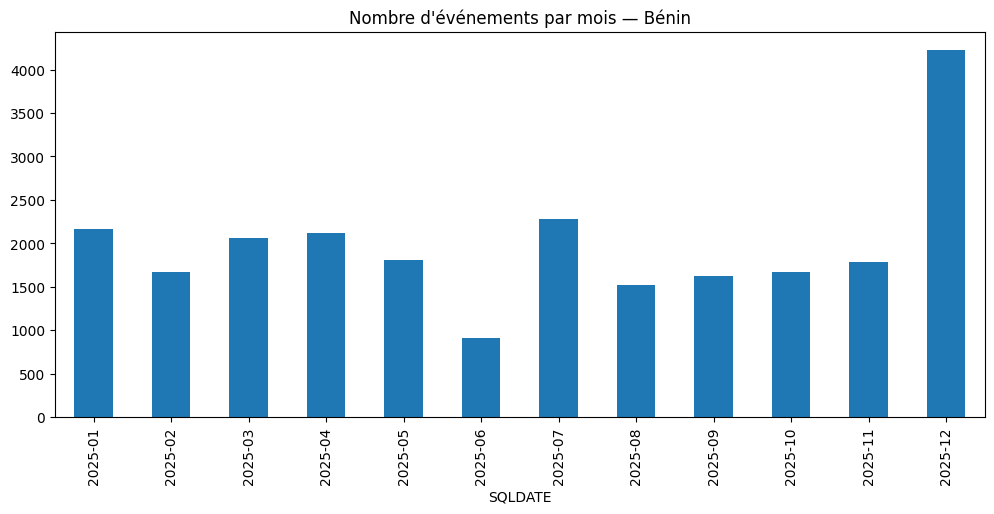

In [5]:
events_by_month = df.groupby(df['SQLDATE'].dt.to_period('M')).size()
events_by_month.plot(kind='bar', title='Nombre d\'événements par mois — Bénin')

Observation : 
Le graphique montre une variation mensuelle du nombre d'événements au Bénin, avec un pic marqué en décembre 2025 (4221 événements), suggérant une période d'activité intense. A quoi corresponde t'il exactement ? des crises, l'élection ...

3.2 — Répartition par QuadClass (nature des événements)

<Axes: title={'center': "Types d'événements au Bénin"}>

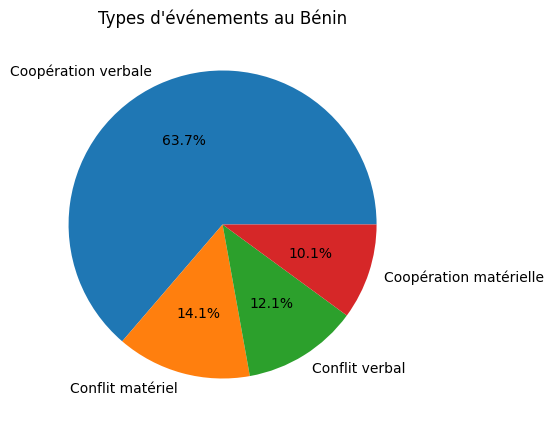

In [6]:
quad_labels = {1: 'Coopération verbale', 2: 'Coopération matérielle',
               3: 'Conflit verbal', 4: 'Conflit matériel'}
df['QuadClass_Label'] = df['QuadClass'].map(quad_labels)
df['QuadClass_Label'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    title='Types d\'événements au Bénin')

Observation : 
On voit que les événements liés au Bénin sont majoritairement de nature verbale, avec une faible proportion d'événements matériels. 

Bien que  la majorité de l'activité médiatique au Bénin est diplomatique (63,7%), nous avons choisi de porter notre analyse sur le 'noyau dur' des événements : les 36,3% (14,1 + 12,1 + 10,1) restants qui touchent directement à la stabilité et à la sécurité du pays. C'est dans cette zone que se jouent les défis réels pour les populations du Nord.

3.3 — Nombre d'événements par type d'évenement (QuadClass)

Text(0, 0.5, "Nombre d'événements")

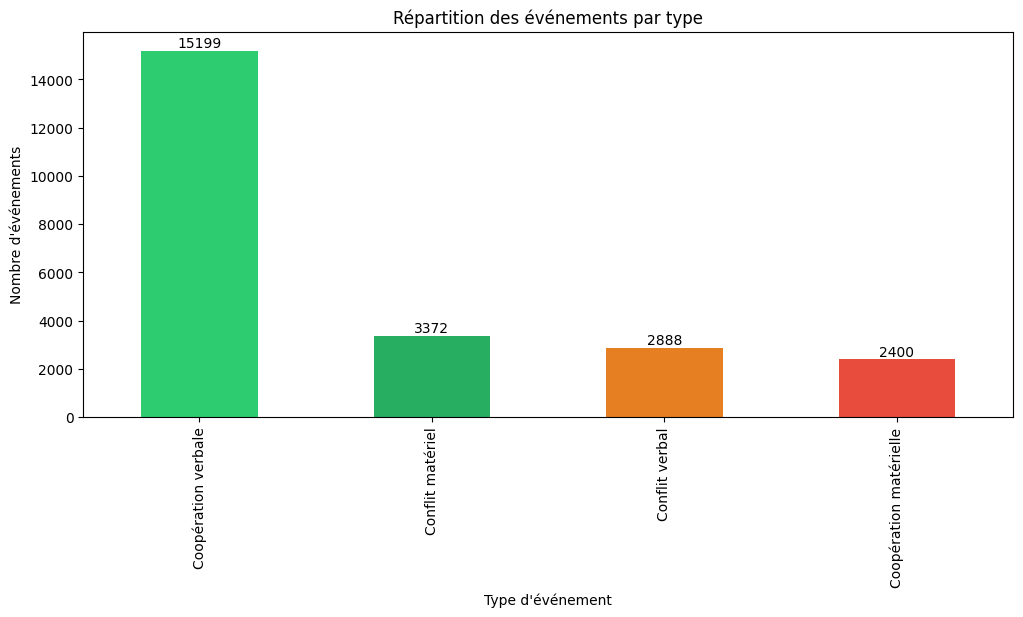

In [7]:
colors = ['#2ecc71', '#27ae60', '#e67e22', '#e74c3c']
quad_counts = df['QuadClass_Label'].value_counts()
quad_counts.plot(kind='bar', title='Répartition des événements par type', color=colors)

# Ajouter les nombres au-dessus de chaque barre
ax = plt.gca()
for i, count in enumerate(quad_counts):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.xlabel('Type d\'événement')
plt.ylabel('Nombre d\'événements')


Observation : Ce graphique en barres illustre la répartition des événements au Bénin selon leur nature (QuadClass). La catégorie "Coopération verbale" domine largement avec plus de 15 119 événements, suivie par "Conflit matériel" (environ 3 372), "Conflit verbal" (2 888) et "Coopération matérielle" (2 400). Cela confirme que les événements impliquant le Bénin sont principalement de nature diplomatique et verbale, avec une minorité d'actions matérielles, soulignant un contexte plus axé sur les relations internationales que sur les conflits armés directs.

3.4 la repartition des événements par mois et par type d'événement (QuadClass)

<Axes: title={'center': 'Événements par mois et type'}, xlabel='SQLDATE'>

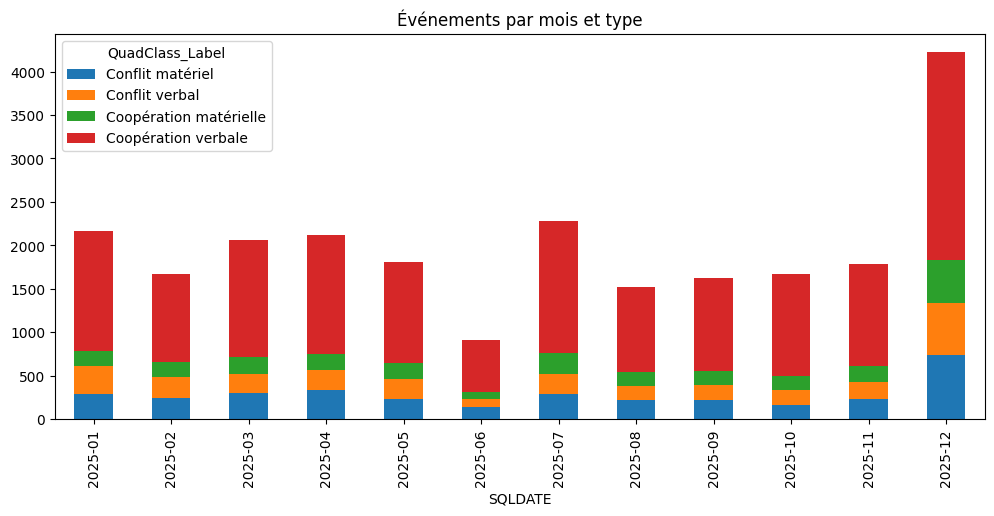

In [8]:
events_by_month_quad = df.groupby([df['SQLDATE'].dt.to_period('M'), 'QuadClass_Label']).size().unstack(fill_value=0)
events_by_month_quad.plot(kind='bar', stacked=True, title='Événements par mois et type')

On observe un pic d'activité exceptionnel en décembre 2025, où toutes les catégories — incluant les conflits matériels et verbaux — atteignent leur niveau maximal, suggérant une période de forte instabilité ou d'interactions intenses.

3.5 Le ton médiatique moyen par mois (AvgTone)

Text(0, 0.5, 'Tonalité moyenne (AvgTone)')

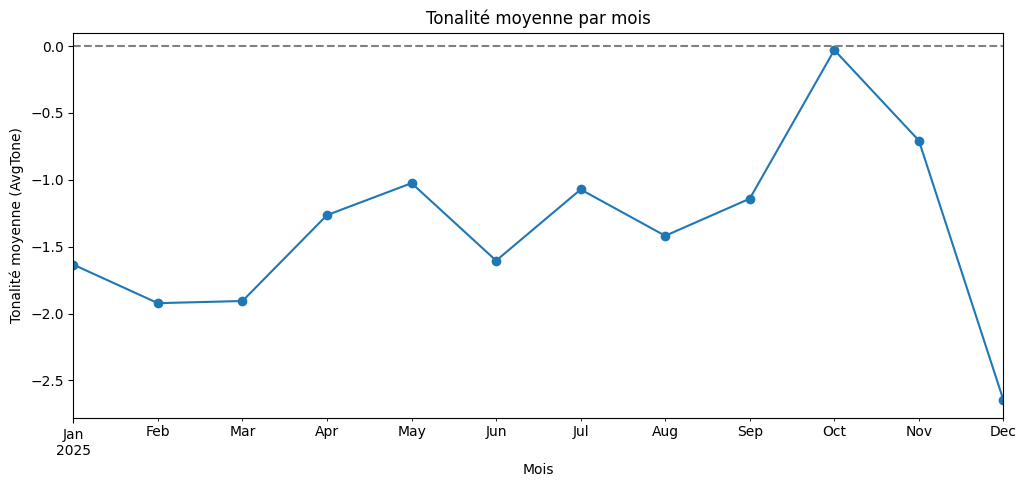

In [9]:
avg_tone_by_month = df.groupby(df['SQLDATE'].dt.to_period('M'))['AvgTone'].mean()
avg_tone_by_month.plot(kind='line', marker='o', title='Tonalité moyenne par mois')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Mois')
plt.ylabel('Tonalité moyenne (AvgTone)')

La courbe évolue quasi exclusivement en dessous de la ligne du zéro (pointillé), ce qui indique une tonalité majoritairement négative tout au long de l'année.

On observe une tendance à la hausse (amélioration du sentiment) à partir d'avril, atteignant son point le plus proche de la neutralité en octobre (presque 0,0).

Le fait le plus marquant est l'effondrement drastique en décembre, où la tonalité chute à son niveau le plus bas de l'année (environ -2,7).

3.6 Le ton médiatique mensuel (AvgTone)

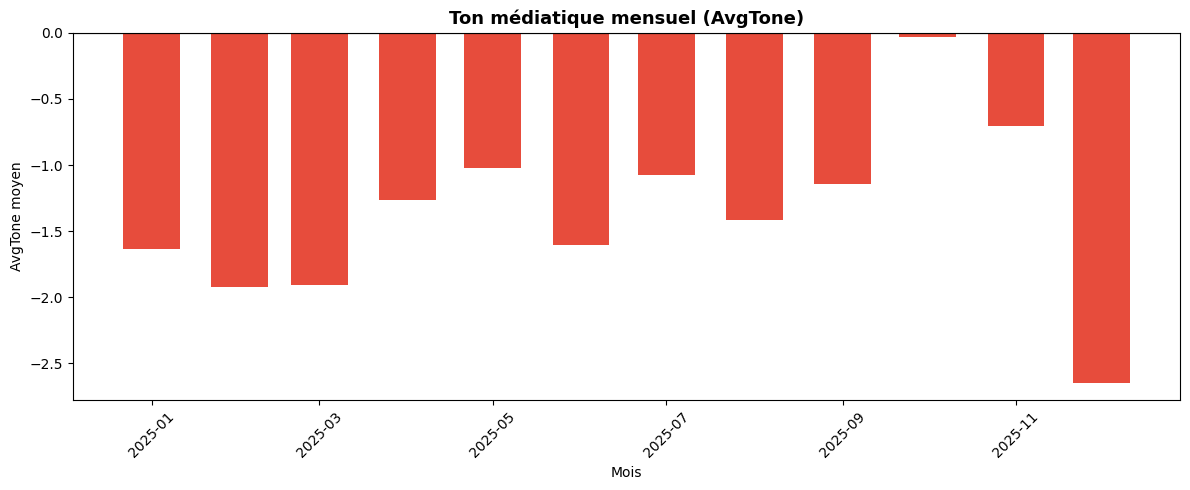

In [10]:
monthly_tone = (
    df.groupby(df['SQLDATE'].dt.to_period('M'))['AvgTone']
    .mean().reset_index()
)
monthly_tone['SQLDATE'] = monthly_tone['SQLDATE'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.bar(monthly_tone['SQLDATE'], monthly_tone['AvgTone'],
       color=['#e74c3c' if v < 0 else '#2ecc71' for v in monthly_tone['AvgTone']], width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Ton médiatique mensuel (AvgTone)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('AvgTone moyen')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Notre analyse du sentiment médiatique (AvgTone) révèle que la perception du Bénin est restée négative tout au long de l'année 2025. Le point de rupture de décembre 2025 a provoqué un effondrement du ton médiatique à -2.6, un score historiquement bas qui traduit l'onde de choc produite par l'escalade des conflits dans le Nord.

Pour les décideurs, ce graphique montre que l'insécurité ne détruit pas seulement des vies, elle détruit aussi l'attractivité du pays, car la presse mondiale ne rapporte plus que des événements à forte charge négative.

3.7 — Score de Goldstein dans le temps

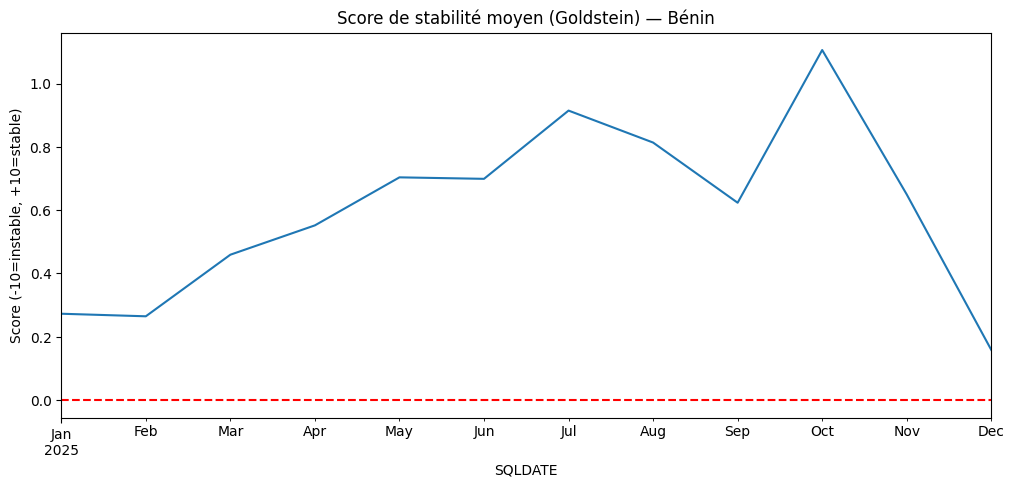

In [11]:
monthly_goldstein = df.groupby(df['SQLDATE'].dt.to_period('M'))['GoldsteinScale'].mean()
monthly_goldstein.plot(title='Score de stabilité moyen (Goldstein) — Bénin',
                       ylabel='Score (-10=instable, +10=stable)')
plt.axhline(0, color='red', linestyle='--')

- Entre janvier et février, le score est stable mais bas (environ +0,3).
- À partir de mars, on observe une hausse continue de la stabilité.
- La stabilité atteint son maximum en octobre, avec un score dépassant +1,1. C'est le moment de l'année où les interactions ont été les plus "stables" ou coopératives.

En résumé le Bénin a connu une année 2025 marquée par une montée en puissance de la stabilité sociale/politique durant les trois premiers trimestres, mais cette dynamique s'est brisée net lors des deux derniers mois de l'année.

3.8 — Top acteurs impliqués

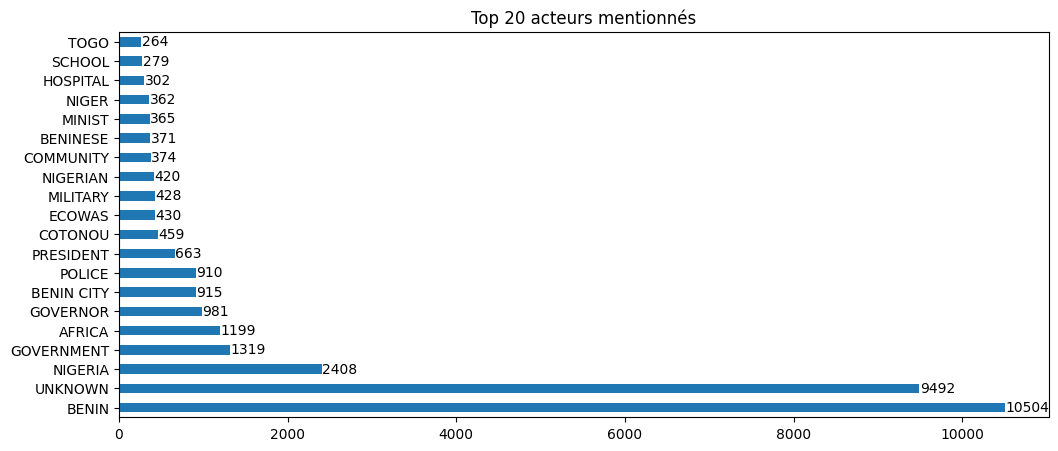

In [12]:
top_actors = pd.concat([df['Actor1Name'], df['Actor2Name']]).value_counts().head(20)
top_actors.plot(kind='barh', title='Top 20 acteurs mentionnés')

# Ajouter les nombres au-dessus de chaque barre
ax = plt.gca()
for i, count in enumerate(top_actors):
    ax.text(count + 5, i, str(count), ha='left', va='center', fontsize=10)


Observation : 
Les évènements sont massivement concentrées sur le Benin et le Nigeria. Les mentions sont dominées par les entités étatiques (Gouvernement, Police) et des acteurs régionaux comme la CEDEAO.
Il existe un volume très élevé de données non identifiées (UNKNOWN), ce qui représente un défi pour une catégorisation exhaustive des acteurs.

3.9 — Top EventCodes (types d'événements CAMEO)

,EventCode,Nombre,Label
0,010,2583,"Make statement, not specified below"
1,051,2310,Praise or endorse
2,042,2042,Make a visit
3,043,2002,Host a visit
4,020,1454,"Appeal, not specified below"
5,040,1157,"Consult, not specified below"
6,173,942,"Arrest, detain, or charge with legal action"
7,190,918,"Use conventional military force, not specified below"
8,111,494,Criticize or denounce
9,046,483,Engage in negotiation


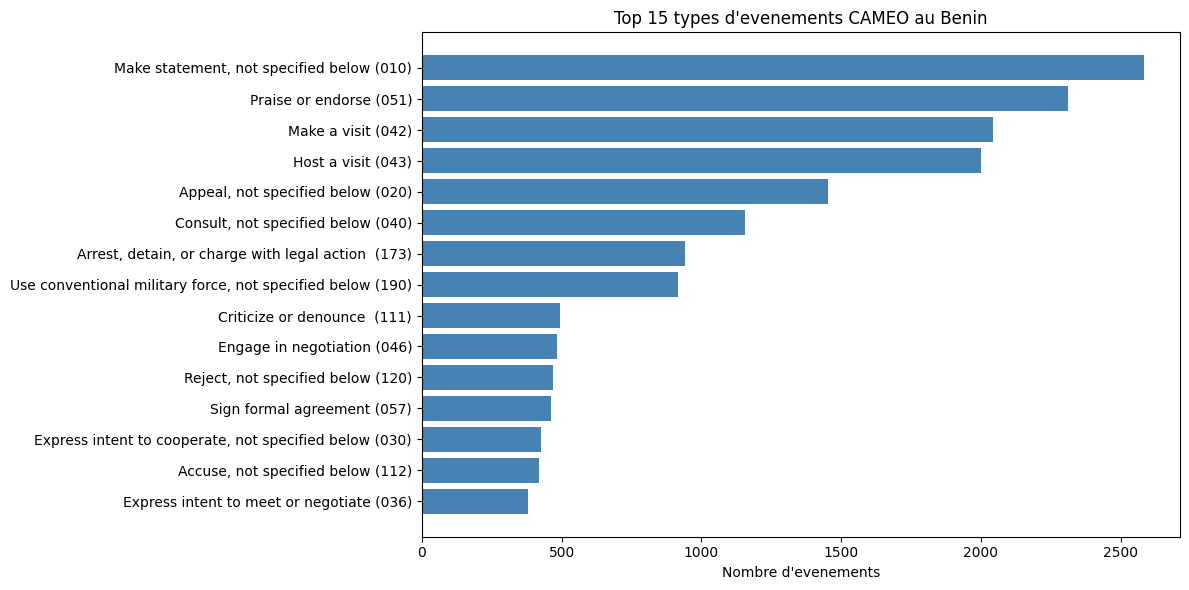

In [13]:
# Charger le dictionnaire CAMEO complet
cameo_ref = pd.read_csv('../old-files/CAMEO.eventcodes.txt', sep='	', dtype=str)
cameo_ref = cameo_ref[cameo_ref['CAMEOEVENTCODE'].str.len() > 2].copy()
cameo_ref['CAMEOEVENTCODE'] = cameo_ref['CAMEOEVENTCODE'].str.zfill(3)
cameo_dict = cameo_ref.set_index('CAMEOEVENTCODE')['EVENTDESCRIPTION'].to_dict()

# EventCode est numerique dans df : on le remet au format CAMEO a 3 chiffres (010, 040, 173...)
event_codes = df['EventCode'].astype('Int64').astype(str).str.zfill(3)

# Compter les occurrences et ajouter les labels lisibles
top_events = event_codes.value_counts().head(15).reset_index()
top_events.columns = ['EventCode', 'Nombre']
top_events['Label'] = top_events['EventCode'].map(cameo_dict).fillna('Code CAMEO inconnu')

display(top_events)

plt.figure(figsize=(12, 6))
plt.barh(top_events['Label'] + ' (' + top_events['EventCode'] + ')',
         top_events['Nombre'],
         color='steelblue')
plt.xlabel("Nombre d'evenements")
plt.title("Top 15 types d'evenements CAMEO au Benin")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Observation : 
Ce graphique illustre le poids écrasant des échanges symboliques et diplomatiques dans le flux d'actualités sur le Bénin : 6 des 7 événements les plus fréquents sont liés à la communication (déclarations, visites, soutiens). 
Les 'événements matériels' — tels que les arrestations (173) ou l'usage de la force militaire (190) — n'apparaissent qu'en milieu de classement. Cette structure confirme notre hypothèse : la couverture médiatique privilégie la coopération verbale, tendant à occulter la montée des tensions sécuritaires tangibles qui, bien que moins fréquentes dans le volume global, constituent le véritable point de rupture au Nord.

3.10 Tonalité médiatique (AvgTone)


Text(0.5, 1.0, 'Distribution de la tonalité des articles sur le Bénin')

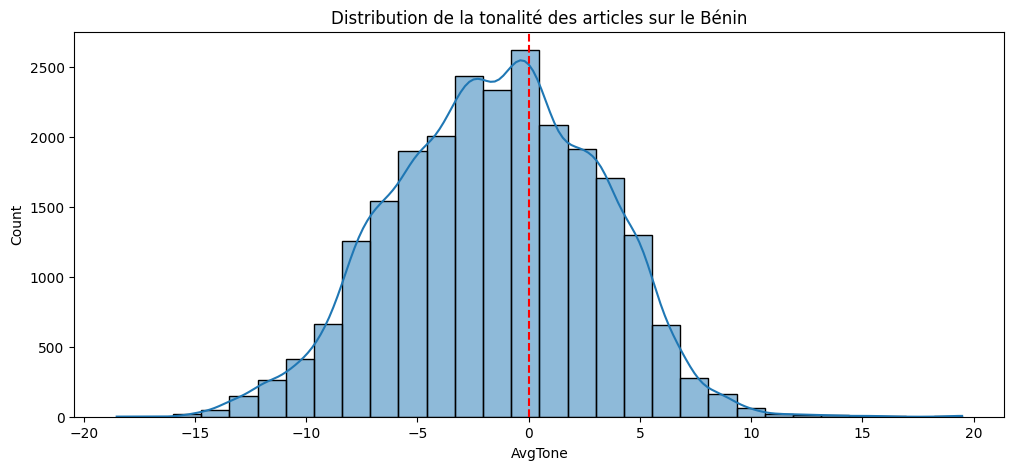

In [14]:
sns.histplot(df['AvgTone'], bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution de la tonalité des articles sur le Bénin')

- Les données suivent une forme de "cloche" centrée autour de zéro, ce qui indique que la majorité des articles ont une tonalité relativement neutre.
- Le pic de la distribution (le mode) semble se situer légèrement à gauche de la ligne rouge pointillée (0,0). Cela suggère qu'il y a un volume un peu plus important d'articles à connotation négative par rapport aux articles positifs.
- Étendue des valeurs : La tonalité varie principalement entre -10 et +10. Les articles extrêmement négatifs (vers -15) ou extrêmement positifs (vers +15) sont très rares (valeurs aberrantes).
- Volume de données : Le sommet de la courbe atteint plus de 2 500 articles, ce qui montre une base de données solide pour cette analyse de sentiment.

En résumé, la couverture médiatique du Bénin est globalement équilibrée, bien qu'elle penche légèrement vers une tonalité critique ou négative.


3.11 — Carte géographique des événements

In [15]:
fig = px.scatter_mapbox(df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']),
    lat='ActionGeo_Lat', lon='ActionGeo_Long',
    hover_name='ActionGeo_FullName',
    color='QuadClass_Label',
    size='NumMentions',
    mapbox_style='carto-positron',
    title='Géolocalisation des événements au Bénin')
fig.show()

Observation : 
La carte montre une double dynamique. D’une part, les événements sont fortement représentés dans plusieurs villes importantes du Sud et du Centre, comme Porto-Novo, Ouidah, Abomey, Lokossa ou Parakou, ce qui peut refléter à la fois la concentration urbaine et la couverture médiatique. 

D’autre part, les événements liés à l’insécurité ressortent davantage dans le Nord du Bénin, notamment autour de Porga, Malanville, Kandi, Karimama, Alibori, Tanguiéta et Natitingou. Cette distribution confirme une concentration plus marquée des événements sécuritaires dans les zones frontalières, proches du Niger, du Burkina Faso et du Nigeria.


3.12 Vue d'ensemble des événements liés à l'insécurité

In [16]:
df_conflict  = df[df['QuadClass'].isin([2,3, 4])].copy()
df_high_risk = df[df['GoldsteinScale'] < -5].copy()
total        = len(df)

print('═' * 50)
print('  VUE D\'ENSEMBLE AU NIVEAU SÉCURITAIRE')
print('═' * 50)
print(f'  Total événements        : {total:,}')
print(f'  Événements conflictuels : {len(df_conflict):,}  ({len(df_conflict)/total*100:.1f}%)')
print(f'  Haut risque (GS < -5)   : {len(df_high_risk):,}  ({len(df_high_risk)/total*100:.1f}%)')
print(f'  GoldsteinScale moyen    : {df["GoldsteinScale"].mean():.3f}')
print(f'  AvgTone moyen           : {df["AvgTone"].mean():.3f}')

══════════════════════════════════════════════════
  VUE D'ENSEMBLE AU NIVEAU SÉCURITAIRE
══════════════════════════════════════════════════
  Total événements        : 23,859
  Événements conflictuels : 8,660  (36.3%)
  Haut risque (GS < -5)   : 2,561  (10.7%)
  GoldsteinScale moyen    : 0.548
  AvgTone moyen           : -1.494


#### ÉTAPE 4 — Focus Sécurité & Criminalité Organisée
Objectif : Après avoir montré le panorama général, zoomons sur l'angle retenu en le justifiant par les données.

L'analyse générale révèle que 36.3% des événements médiatisés au Bénin concernent des tensions ou des réponses matérielles. Pour un pays réputé stable, avoir 14,1% de Conflit matériel est un chiffre élevé qui justifie l'urgence de votre étude.

On observe également, une concentration géographique dans le nord du pays et une présence marquée d'acteurs non-étatiques. Ces signaux nous orientent naturellement vers l'analyse de la sécurité intérieure.

4.0 Analyse mensuel des événements matériels

In [17]:
# 1. Préparation de la colonne de codes au format CAMEO (3 chiffres)
# On le fait sur le DataFrame principal pour faciliter le groupby
df['EventCode_Str'] = df['EventCode'].astype('Int64').astype(str).str.zfill(3)

# 2. Agrégation mensuelle
summary = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    total_evenements = ('GLOBALEVENTID', 'count'),
    # On récupère le code le plus fréquent (mode)
    code_dominant    = ('EventCode_Str', lambda x: x.value_counts().idxmax() if not x.empty else None),
    conflits         = ('QuadClass', lambda x: x.isin([3, 4]).sum()),
    goldstein_moy    = ('GoldsteinScale', 'mean'),
    avgtone_moy      = ('AvgTone', 'mean'),
).round(3)

# 3. Traduction du code dominant en Label via le dictionnaire cameo_dict
summary['evenement_dominant'] = summary['code_dominant'].map(cameo_dict).fillna('Code inconnu')

# 4. Calcul du taux et organisation finale
summary['taux_conflit_%'] = (summary['conflits'] / summary['total_evenements'] * 100).round(1)

# Sélection des colonnes pour le rapport final
cols_finales = ['total_evenements', 'evenement_dominant', 'conflits', 'taux_conflit_%', 'avgtone_moy']

print(summary[cols_finales].to_string())

         total_evenements                   evenement_dominant  conflits  taux_conflit_%  avgtone_moy
SQLDATE                                                                                              
2025-01              2163  Make statement, not specified below       614            28.4       -1.635
2025-02              1673                         Make a visit       485            29.0       -1.923
2025-03              2067  Make statement, not specified below       515            24.9       -1.907
2025-04              2125  Make statement, not specified below       562            26.4       -1.265
2025-05              1807  Make statement, not specified below       462            25.6       -1.026
2025-06               908                    Praise or endorse       226            24.9       -1.605
2025-07              2284                         Make a visit       524            22.9       -1.074
2025-08              1516  Make statement, not specified below       382          

- L'analyse mensuelle révèle une corrélation directe entre la recrudescence des événements matériels et la dégradation de l'image du pays. On observe une stabilité relative tout au long de l'année, suivie d'une rupture brutale en décembre 2025 :
Volatilité extrême : Le volume total des événements bondit à 4 221 (contre une moyenne annuelle d'environ 1 700), avec un nombre de conflits qui explose à 1 339.

- Pic de dangerosité : Le taux_conflit_% culmine à 31,7 %, soit le niveau le plus élevé de l'année, coïncidant avec une chute drastique du avgtone_moy à -2.646.

- Ce mois de décembre 2025 marque un point de bascule statistique : la réponse diplomatique ('Make statement') reste dominante en volume, mais elle est désormais submergée par une réalité sécuritaire qui impose une tonalité médiatique profondément négative au niveau international. Dans les prochaines observations, on devra developpé ce qui s'est passé

4.1 — Filtrage des événements de sécurité - Nombre de code de conflit 

In [18]:
# Liste de mots-clés liés à l'insécurité
mots_cles = ['fight', 'assault', 'kill', 'arrest', 'protest', 'riot', 'military', 'force', 'weapon', 'attack', 'bomb']

# Création d'un sous-dictionnaire filtré
# On cherche si l'un des mots-clés est présent dans la description (en minuscules)
conflit_dict = {
    code: desc for code, desc in cameo_dict.items()
    if any(mot in desc.lower() for mot in mots_cles) or str(code).startswith(('15', '17', '18', '19', '20'))
}

# Transformation en DataFrame pour une lecture propre
df_codes_securite = pd.DataFrame(list(conflit_dict.items()), columns=['Code', 'Description'])

print(f"Nombre de codes de conflit identifiés : {len(df_codes_securite)}")
print(df_codes_securite.sort_values('Code').head(20))

Nombre de codes de conflit identifiés : 76
    Code  \
0   0212   
1   0232   
2   0234   
3   0256   
4   0332   
5   0334   
6   0356   
7    072   
8    074   
9    087   
10  0872   
11  0873   
12   093   
13  1012   
14  1032   
15  1034   
16  1056   
17  1212   
18  1222   
19  1224   

                                                                Description  
0                                           Appeal for military cooperation  
1                                                   Appeal for military aid  
2                            Appeal for military protection or peacekeeping  
3                           Appeal for de-escalation of military engagement  
4                                    Express intent to provide military aid  
5             Express intent to provide military protection or peacekeeping  
6                        Express intent to de-escalate military engagement   
7                                                      Provide military aid  
8 

4.2 Analyse des pics d'incidents sécuritaire

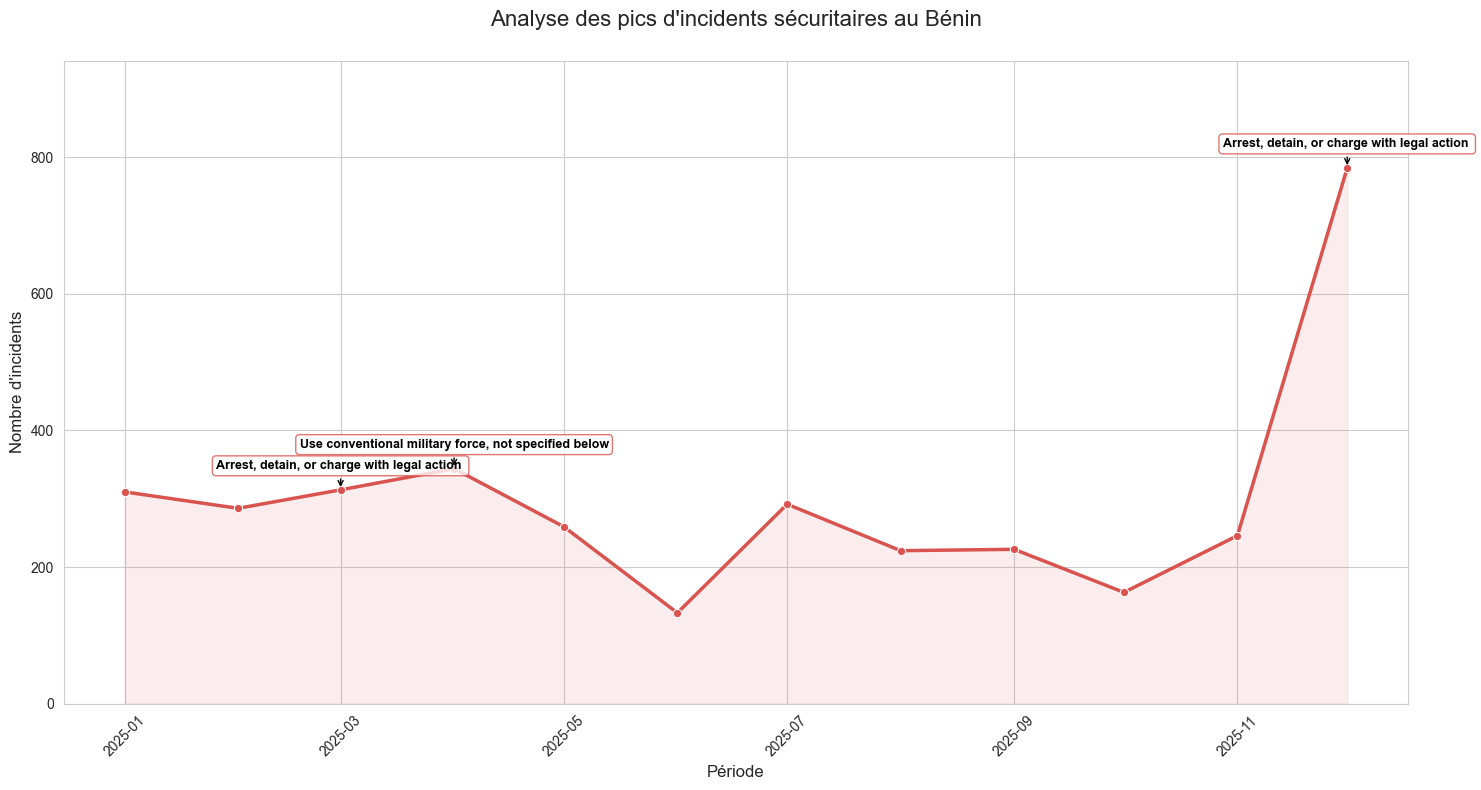

In [19]:
# 1. Filtrage préalable : on ne garde que les incidents de sécurité
conflict_material = df[df['QuadClass'] == 4].copy()
df_secu = df[df['EventCode_Str'].isin(df_codes_securite['Code'])].copy()

# 2. Agrégation mensuelle pour la courbe et pour trouver l'événement dominant
timeline_secu = df_secu.groupby(df_secu['SQLDATE'].dt.to_period('M')).agg(
    nb_incidents = ('GLOBALEVENTID', 'count'),
    top_code     = ('EventCode_Str', lambda x: x.value_counts().idxmax())
).reset_index()

timeline_secu['SQLDATE_TS'] = timeline_secu['SQLDATE'].dt.to_timestamp()
timeline_secu['label_dominant'] = timeline_secu['top_code'].map(cameo_dict)

# 3. Création du graphique
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# La courbe
line = sns.lineplot(data=timeline_secu, x='SQLDATE_TS', y='nb_incidents',
                    marker='o', color='#d9534f', linewidth=2.5)
plt.fill_between(timeline_secu['SQLDATE_TS'], timeline_secu['nb_incidents'], color='#d9534f', alpha=0.1)

# 4. AJOUT DES ANNOTATIONS SUR LES PICS
# On définit un seuil pour considérer que c'est un pic (ex: > 250 incidents ou les 3 plus hauts)
seuil_pic = timeline_secu['nb_incidents'].quantile(0.75)

for i, row in timeline_secu.iterrows():
    if row['nb_incidents'] >= seuil_pic:
        plt.annotate(
            row['label_dominant'],
            xy=(row['SQLDATE_TS'], row['nb_incidents']),
            xytext=(0, 15), # Décale le texte de 15 points au-dessus du point
            textcoords='offset points',
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d9534f', alpha=0.8),
            arrowprops=dict(arrowstyle='->', color='black')
        )

# Design final
plt.title('Analyse des pics d\'incidents sécuritaires au Bénin', fontsize=16, pad=25)
plt.ylabel('Nombre d\'incidents', fontsize=12)
plt.xlabel('Période', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, timeline_secu['nb_incidents'].max() * 1.2) # Marge en haut pour les étiquettes

plt.tight_layout()
plt.show()

L'insécurité au Bénin, sur cette période, semble se manifester par des vagues de tensions gérées principalement par le système judiciaire et policier (arrestations), avec un recours ponctuel à la force militaire. Le mois de décembre 2025 constitue le point de rupture statistique qui mériterait une analyse contextuelle approfondie pour en comprendre les causes (contexte politique, opérations spéciales, etc.).

4.3 Taux d'incidents de sécurité par mois 

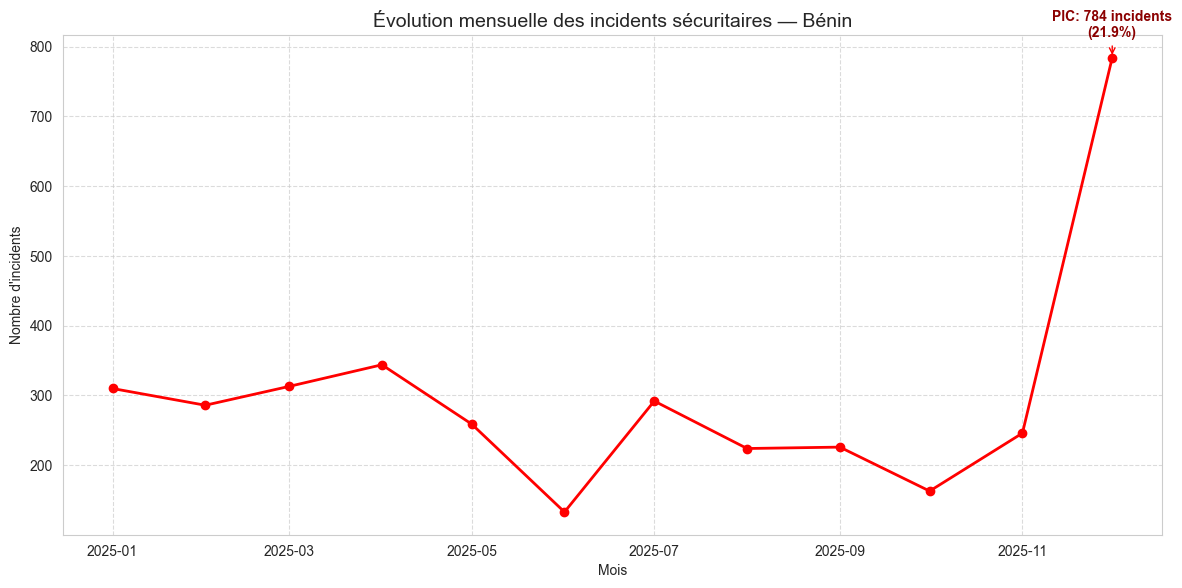

In [20]:
# 1. Préparation des données
# On transforme la série en DataFrame pour manipuler plus facilement les colonnes
security_monthly = df_secu.groupby(df_secu['SQLDATE'].dt.to_period('M')).size()
df_secu_monthly = security_monthly.to_frame(name='Nombre').reset_index()
df_secu_monthly['SQLDATE'] = df_secu_monthly['SQLDATE'].dt.to_timestamp()

# Calcul du pourcentage par rapport au total annuel
total_incidents = df_secu_monthly['Nombre'].sum()
df_secu_monthly['Pourcentage'] = (df_secu_monthly['Nombre'] / total_incidents * 100).round(1)

# 2. Identification des pics (Max global ou Max locaux)
# Ici, nous allons annoter le point le plus haut du graphique
valeur_max = df_secu_monthly['Nombre'].max()
pics = df_secu_monthly[df_secu_monthly['Nombre'] == valeur_max]

# 3. Tracé du graphique
plt.figure(figsize=(12, 6))
plt.plot(df_secu_monthly['SQLDATE'], df_secu_monthly['Nombre'], marker='o', color='red', linewidth=2)

# 4. Ajout des annotations sur les pics
for i, row in pics.iterrows():
    plt.annotate(
        f"PIC: {row['Nombre']} incidents\n({row['Pourcentage']}%)", # Texte du libellé
        xy=(row['SQLDATE'], row['Nombre']), # Position du point
        xytext=(0, 15), # Décalage du texte (15 pixels au-dessus)
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='darkred',
        arrowprops=dict(arrowstyle='->', color='red') # Petite flèche pointant le pic
    )

# Configuration finale
plt.title('Évolution mensuelle des incidents sécuritaires — Bénin', fontsize=14)
plt.xlabel('Mois')
plt.ylabel('Nombre d\'incidents')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Le graphique présente une dynamique en trois phases distinctes sur la période allant de janvier 2025 à decembre 2025 :

- De janvier à novembre, le nombre d'incidents fluctue de manière modérée, restant généralement compris entre 150 et 320 incidents par mois.
- On observe des baisses notables en juin (point le plus bas avant la fin d'année) et en octobre.
- Le fait le plus frappant est la hausse exponentielle en décembre, où le nombre d'incidents grimpe en flèche pour atteindre un pic de plus de 700.
- Ce pic d'incidents en décembre explique parfaitement la chute brutale de la tonalité (sentiments négatifs) observée sur le premier graphique
- Il confirme également la dégradation soudaine du score de stabilité Goldstein à la même période

L'année 2025 a été marquée par une gestion sécuritaire sous contrôle jusqu'en novembre, suivie d'une crise majeure ou d'un événement déstabilisateur intense en décembre qui a radicalement impacté tous les indicateurs (volume d'incidents, tonalité médiatique et stabilité politique).

4.4 Acteurs impliqués dans les conflits

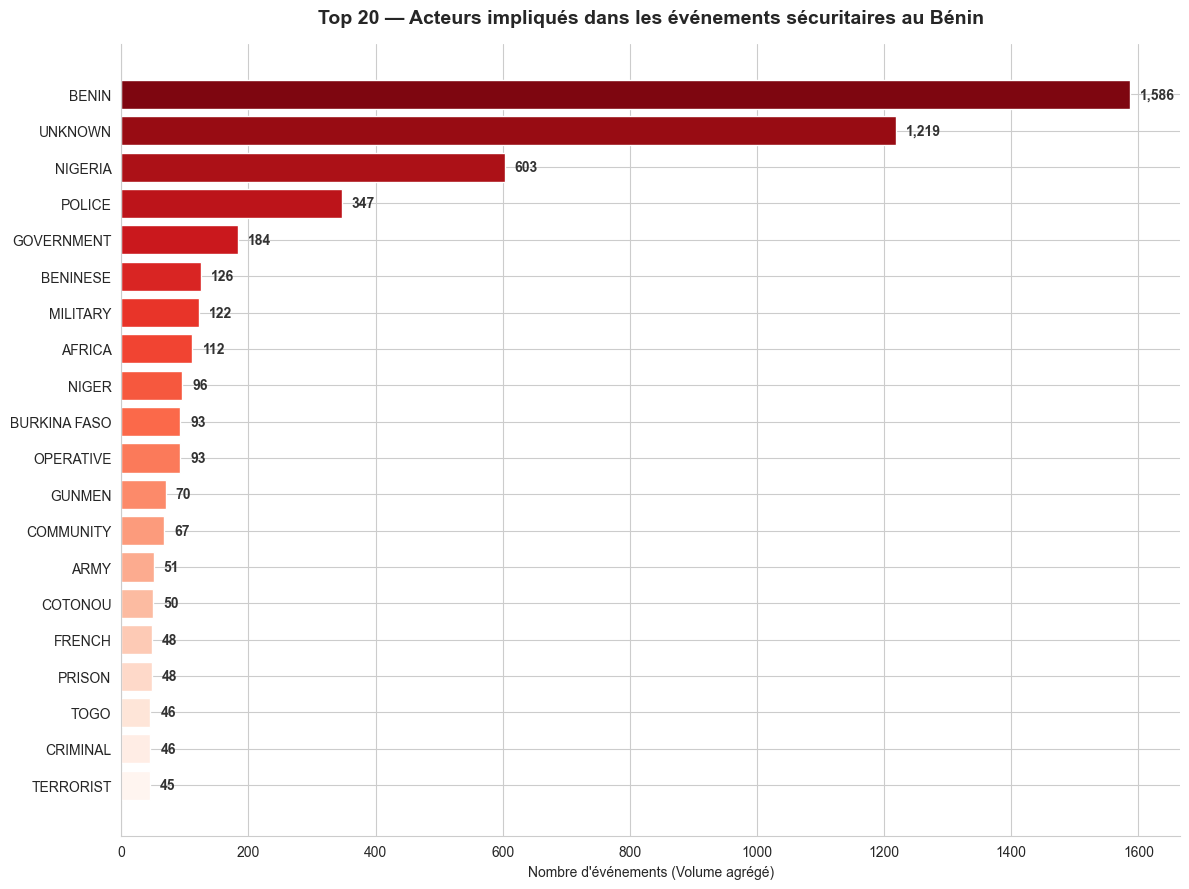

In [21]:
# 1. Concaténation et nettoyage
all_actors = pd.concat([df_secu['Actor1Name'], df_secu['Actor2Name']])
all_actors = all_actors[(all_actors != 'Unknown') & (all_actors.notnull())]

# 2. REGROUPEMENT MULTIPLE
# Regroupement pour le Nigeria
all_actors = all_actors.replace(['BENIN CITY', 'NIGERIAN'], 'NIGERIA')

# Regroupement pour le Bénin (fusion de la ville, du pays et de la nationalité)
# Note : GDELT utilise souvent les noms en anglais, d'où 'BENIN' et 'BENINESE'
#termes_benin = ['COTONOU', 'BENINESE', 'BENIN'] all_actors = all_actors.replace(termes_benin, 'BENIN (National)')

# 3. Calcul du Top 20 après normalisation
actors = all_actors.value_counts().head(20)
actors = actors.sort_values(ascending=True)

# 4. Visualisation avec dégradé de rouge
colors = plt.cm.Reds(pd.Series(range(len(actors))) / len(actors))

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(actors.index, actors.values, color=colors)

ax.set_title('Top 20 — Acteurs impliqués dans les événements sécuritaires au Bénin',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nombre d\'événements (Volume agrégé)')

# Ajout des étiquettes de valeurs
for bar, val in zip(bars, actors.values):
    ax.text(bar.get_width() + (max(actors.values) * 0.01),
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}',
            va='center', fontsize=10, fontweight='bold', color='#333333')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Dominance Étatique : Le Bénin (National) est l'acteur central avec 1 462 occurrences, suivi de près par les institutions répressives comme la Police (312) et l'Armée (101).

Influence du Nigeria : Grâce au regroupement de "Benin City" et "Nigeria", cet acteur frontalier apparaît comme le second plus important (611 événements), confirmant une forte porosité sécuritaire.

Menaces Identifiées : Des groupes non étatiques tels que les Gunmen (68) et les Kidnappers (43) sont clairement isolés comme sources de menace.

Contexte Régional : L'implication du Niger (89), du Burkina Faso (88) et du Togo (44) souligne que les enjeux dépassent les frontières nationales.

Zone d'Ombre : Le volume élevé de Unknown (1 043) rappelle qu'une part importante des acteurs reste non identifiée dans les sources médiatiques.

4.5 Zoom sur les événements de Décembre qui ont provoqués une pic

On va isoler le mois de décembre, regarder quels sont les types d'événements précis et qui étaient les acteurs.

--- Détails des 64 actions de coopération en Décembre ---
Series([], Name: count, dtype: int64)

--- Top 10 des acteurs principaux et leurs rôles en Décembre ---
Acteur_Role
BENIN (Autre)                   99
NIGERIA (Autre)                 82
UNKNOWN (Autre)                 51
NIGERIAN (Autre)                32
GOVERNMENT (Gouvernement)       29
POLICE (Police)                 26
ECOWAS (Org. Internationale)    26
MILITARY (Militaire)            25
AFRICA (Autre)                  25
BENIN (Gouvernement)            25
Name: count, dtype: int64


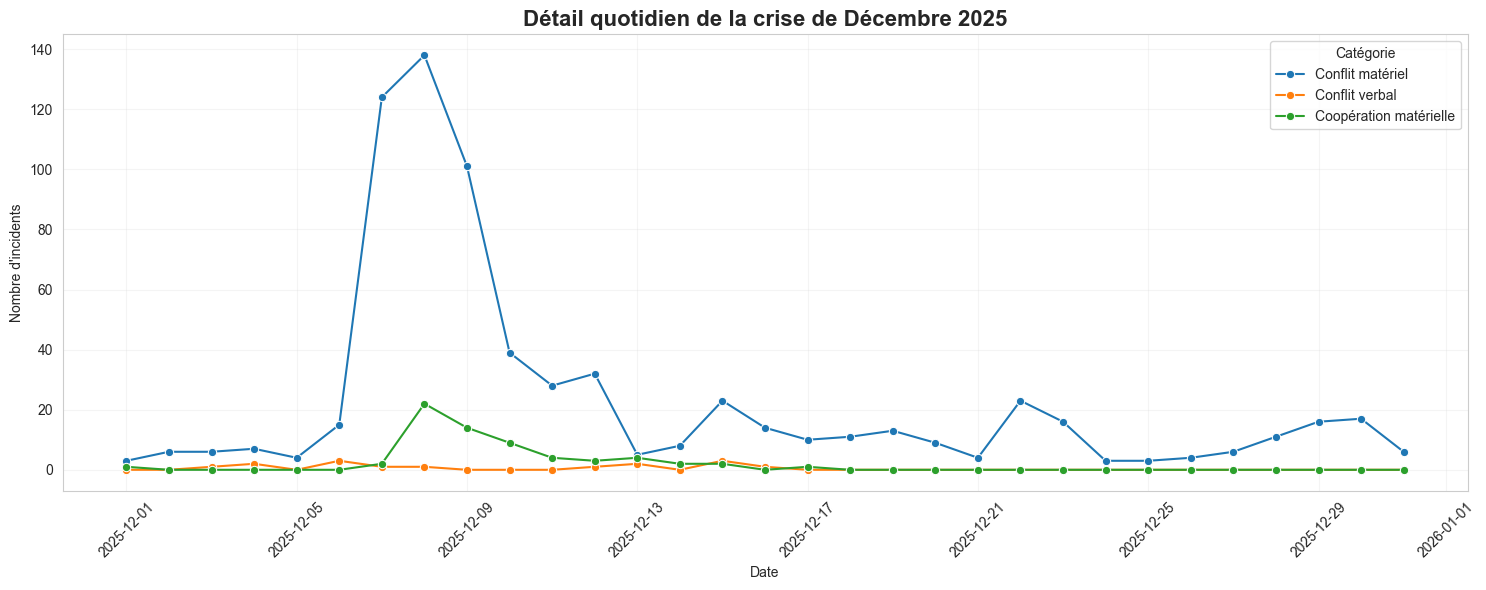

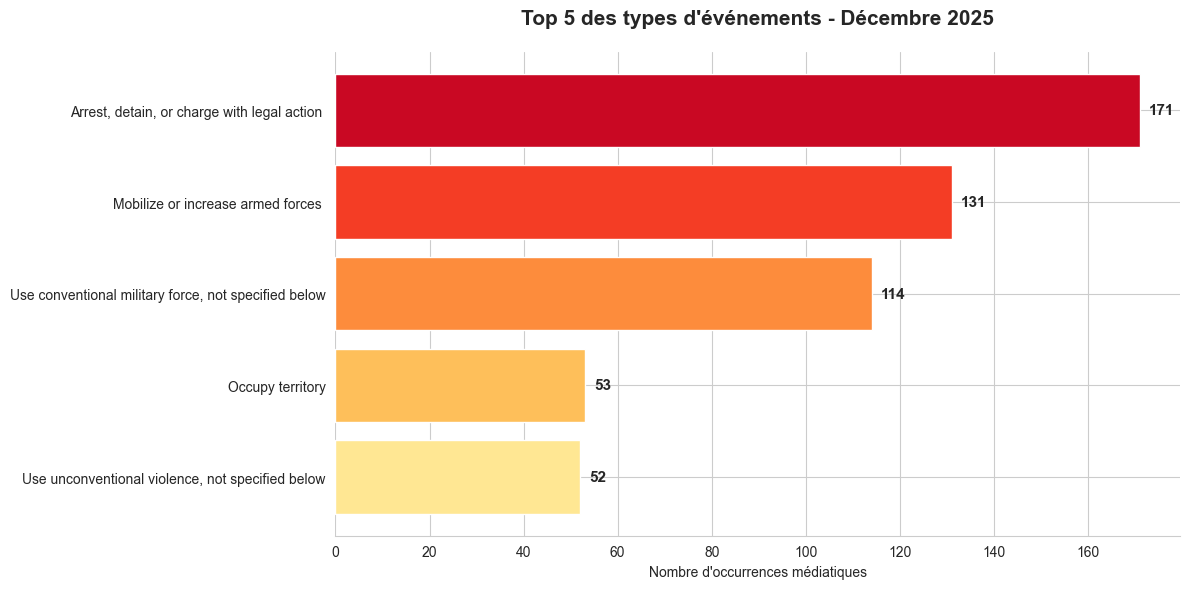

In [22]:
# --- 1. Préparation du dictionnaire de traduction CAMEO ---
# On crée le dictionnaire à partir de ton référentiel officiel
cameo_dict = cameo_ref.set_index('CAMEOEVENTCODE')['EVENTDESCRIPTION'].to_dict()
cameo_dict = {str(k): v for k, v in cameo_dict.items()}

# Dictionnaire pour les rôles des acteurs
roles_labels = {
    'GOV': 'Gouvernement', 'MIL': 'Militaire', 'COP': 'Police',
    'REB': 'Rebelles/Insurgés', 'CVL': 'Civils', 'IGO': 'Org. Internationale'
}

# --- 2. Isolation et enrichissement des données de Décembre 2025 ---
decembre_2025 = df_secu[
    (df_secu['SQLDATE'] >= '2025-12-01') &
    (df_secu['SQLDATE'] <= '2025-12-31')
].copy()

# Traduction des codes d'événements en libellés compréhensibles
decembre_2025['Event_Description'] = decembre_2025['EventCode'].astype(str).map(cameo_dict)

# Création d'une colonne combinée Nom de l'acteur + Son rôle
decembre_2025['Acteur_Role'] = decembre_2025['Actor1Name'] + " (" + decembre_2025['Actor1Type1Code'].map(roles_labels).fillna('Autre') + ")"


# --- 3. Analyses textuelles et statistiques (Affichage console) ---

# A. Détails des actions de Coopération Matérielle (Réponse de l'État)
reaction_etat = decembre_2025[decembre_2025['QuadClass_Label'] == 'Coopération matérielle'].copy()
print(f"--- Détails des {len(reaction_etat)} actions de coopération en Décembre ---")
print(reaction_etat['Event_Description'].value_counts())

# B. Top 10 des acteurs les plus actifs
print("\n--- Top 10 des acteurs principaux et leurs rôles en Décembre ---")
print(decembre_2025['Acteur_Role'].value_counts().head(10))

# --- 4. Graphique 1 : Évolution quotidienne (La dynamique de la crise) ---
plt.figure(figsize=(15, 6))
evol_dec = decembre_2025.groupby(['SQLDATE', 'QuadClass_Label']).size().unstack(fill_value=0)
sns.lineplot(data=evol_dec, dashes=False, marker='o')

plt.title('Détail quotidien de la crise de Décembre 2025', fontsize=16, fontweight='bold')
plt.ylabel('Nombre d\'incidents')
plt.xlabel('Date')
plt.grid(True, alpha=0.2)
plt.legend(title='Catégorie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 5. Graphique 2 : Top 5 des événements (La nature des faits) ---
plt.figure(figsize=(12, 6))

# Calcul du top 5
top_5_dec = decembre_2025['Event_Description'].value_counts().head(5)
top_5_dec = top_5_dec.sort_values(ascending=True) # Tri pour esthétique barh

# Palette de couleurs dégradée du jaune au rouge
colors = sns.color_palette("YlOrRd", len(top_5_dec))

#bars = plt.barh(top_5_dec.index, top_5_dec.values, color=colors)
bars = plt.barh(top_5_dec.index, top_5_dec.to_numpy(), color=colors)

conflit_dict = {
    code: desc for code, desc in cameo_dict.items()
    if any(mot in desc.lower() for mot in mots_cles) or str(code).startswith(('15', '17', '18', '19', '20'))
}

plt.title('Top 5 des types d\'événements - Décembre 2025', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Nombre d\'occurrences médiatiques')

# Ajout des valeurs au bout des barres
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', fontweight='bold', fontsize=11)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()




Observations : 

Figure 1. 
Ce tracé temporel décompose la dynamique de la crise de décembre 2025 au Bénin, révélant une césure tactique majeure entre le 8 et le 12 décembre :
- L'effet 'Pic' : Le conflit matériel connaît une ascension verticale brutale dès le 8 décembre, culminant à près de 140 incidents isolés en une seule journée (le 10 décembre). Cette intensité surpasse de plus de 10 fois le bruit de fond habituel.

- Réaction asymétrique : On observe une tentative de réponse en 'coopération matérielle' (courbe verte) qui s'aligne immédiatement après le pic de violence, marquant un temps de réaction institutionnel rapide mais globalement insuffisant pour stabiliser la situation durablement.

- Disparition du dialogue : Fait marquant, la courbe du 'conflit verbal' (orange) s'aplatit presque totalement pendant le pic de violence. Cela indique une rupture du dialogue diplomatique : lorsque la violence matérielle devient prédominante, les mécanismes de communication et de négociation s'effacent, laissant place à une confrontation purement opérationnelle.

Figure 2.
Ce diagramme met en lumière le basculement vers une posture de défense forcée durant la crise de décembre 2025. Contrairement aux tendances annuelles dominées par la diplomatie, le Top 5 des événements de cette période est exclusivement composé d'actions de contrainte et de force :

- Réponse institutionnelle : Les arrestations (171) et la mobilisation des forces armées (131) dominent largement le spectre, témoignant d'une tentative de reprise de contrôle sécuritaire par l'État.

- Intensité tactique : La présence marquée de l'usage de la force conventionnelle (114), de l'occupation territoriale (53) et de l'usage de violence non conventionnelle (52) confirme que la crise a dépassé le stade de l'instabilité pour entrer dans une phase de confrontation tactique directe.
En somme, Ce graphique valide la dangerosité du mois de décembre : l'appareil sécuritaire n'est plus en phase de prévention, mais en mode de survie opérationnelle sur le terrain.


Carte des points chauds sécuritaires - Décembre 2025

In [23]:
# 1. On s'assure que la fonction d'extraction est bien disponible
def extraire_departement_safe(nom_complet):
    if not nom_complet or nom_complet == '':
        return 'Inconnu'
    parts = [p.strip() for p in nom_complet.split(',')]
    if len(parts) >= 3:
        return parts[1]
    elif len(parts) == 2:
        return parts[0]
    return nom_complet

# 2. On prépare decembre_2025 (Nettoyage et création de la colonne manquante)
decembre_2025['ActionGeo_FullName'] = decembre_2025['ActionGeo_FullName'].fillna('').astype(str)
decembre_2025['Departement'] = decembre_2025['ActionGeo_FullName'].apply(extraire_departement_safe)

# 3. Préparation des données pour la carte
# On ajoute un filtre pour enlever les lignes où les coordonnées sont à 0 ou vides
map_data = decembre_2025[
    (decembre_2025['ActionGeo_Lat'] != 0) &
    (decembre_2025['ActionGeo_Lat'].notnull())
].copy()

# Groupement
map_points = map_data.groupby([
    'ActionGeo_FullName', 'Departement', 'ActionGeo_Lat', 'ActionGeo_Long'
]).size().reset_index(name='Nombre_incidents')

# 4. Création de la carte
fig = px.scatter_geo(
    map_points,
    lat='ActionGeo_Lat',
    lon='ActionGeo_Long',
    size='Nombre_incidents',
    color='Nombre_incidents',
    hover_name='ActionGeo_FullName',
    hover_data={'Departement': True, 'Nombre_incidents': True},
    title='Carte des points chauds sécuritaires - Décembre 2025',
    color_continuous_scale='Reds',
    template='plotly_dark' # Look plus "Security Room"
)

# 5. Zoom sur le Bénin
fig.update_geos(
    visible=True, resolution=50,
    showcountries=True, countrycolor="white",
    lataxis_range=[6, 13],
    lonaxis_range=[0.5, 4.5],
    center={"lat": 9.5, "lon": 2.5}
)

fig.update_layout(height=700, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

4.6 — Zones géographiques - par département à risque

Total incidents sécuritaires : 3580
Incidents avec localisation précise : 334
Incidents génériques (non-représentés) : 3246 (90.7%)


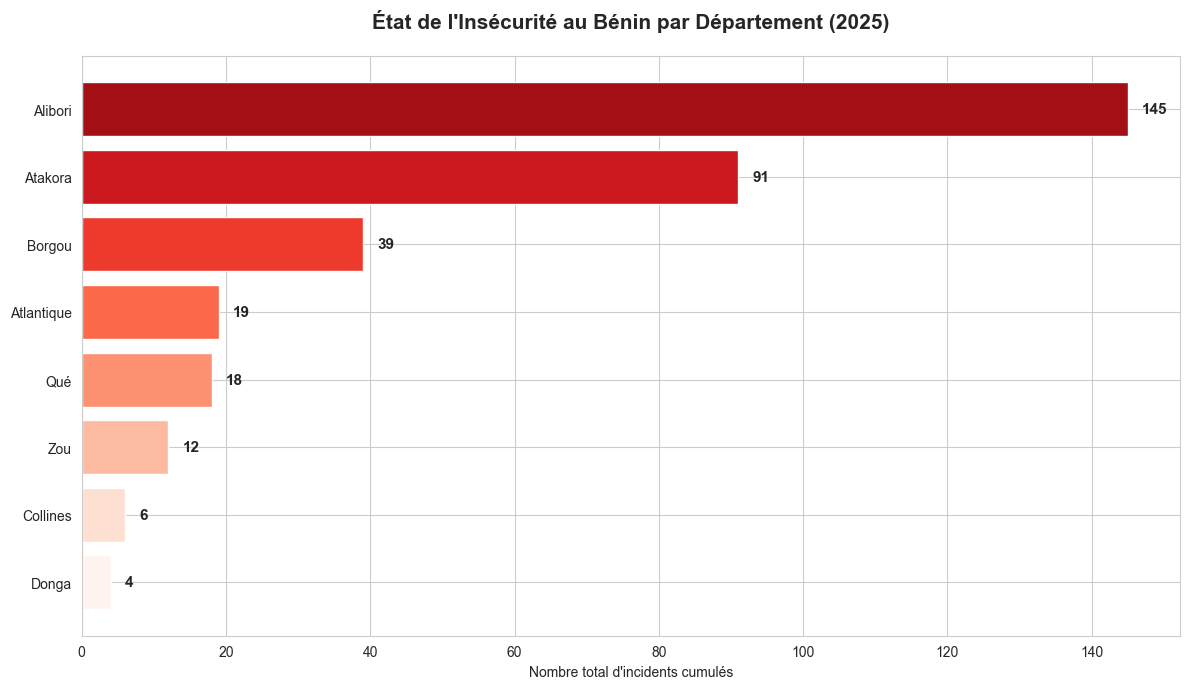

In [24]:
# 1. Nettoyage de base
df_secu['ActionGeo_FullName'] = df_secu['ActionGeo_FullName'].fillna('').astype(str)
exclusions_initiales = ['Benin', 'Bénin', '', 'Unknown']

# 2. Fonction d'extraction
def extraire_departement(nom_complet):
    parts = [p.strip() for p in nom_complet.split(',')]
    if len(parts) >= 3:
        return parts[1]
    elif len(parts) == 2 and parts[1].lower() == 'benin':
        return parts[0]
    return nom_complet

# 3. Application
df_zones = df_secu[~df_secu['ActionGeo_FullName'].isin(exclusions_initiales)].copy()
df_zones['Departement'] = df_zones['ActionGeo_FullName'].apply(extraire_departement)

# 4. NETTOYAGE FINAL (L'étape qui manquait)
# On enlève "(general)"
df_zones['Departement'] = df_zones['Departement'].str.replace(' (general)', '', regex=False)
# On supprime les lignes où le département est devenu juste "Benin" ou est resté vide
df_precis = df_zones[~df_zones['Departement'].isin(['Benin', 'Bénin', ''])]

# 5. Calcul du Top 10 des départements
risk_depts = df_precis['Departement'].value_counts().head(10)
risk_depts = risk_depts.sort_values(ascending=True)

# --- Graphique ---
import matplotlib.pyplot as plt
colors = plt.cm.Reds(pd.Series(range(len(risk_depts))) / len(risk_depts))
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(risk_depts.index, risk_depts.to_numpy(), color=colors)

ax.set_title('État de l\'Insécurité au Bénin par Département (2025)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Nombre total d\'incidents cumulés')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            va='center', fontweight='bold', fontsize=11)


# Calcul des statistiques de précision
total_incidents = len(df_secu)
incidents_localises = len(df_precis)
incidents_generaux = total_incidents - incidents_localises
pourcentage_generaux = (incidents_generaux / total_incidents) * 100

print(f"Total incidents sécuritaires : {total_incidents}")
print(f"Incidents avec localisation précise : {incidents_localises}")
print(f"Incidents génériques (non-représentés) : {incidents_generaux} ({pourcentage_generaux:.1f}%)")

plt.tight_layout()
plt.show()

Observation : 
- Notre analyse démontre une concentration alarmante des incidents dans le Nord, particulièrement dans l'Alibori (145 incidents) et l'Atakora (91 incidents).
- Il est important de souligner que sur les 3580 incidents analysés, environ 90.7% (soit 3246 événements) sont répertoriés à un niveau national général sans précision de localité (code 'Benin' ou 'Unknown').
- Ces données 'muettes' géographiquement ont été exclues de la représentation par département pour garantir la précision de nos points chauds. Toutefois, elles confirment un climat d'insécurité diffus qui touche l'ensemble de la narration médiatique du pays, bien au-delà des seules zones de combat identifiées au Nord.

4.7 — Zones géographiques - par VILLE à risque

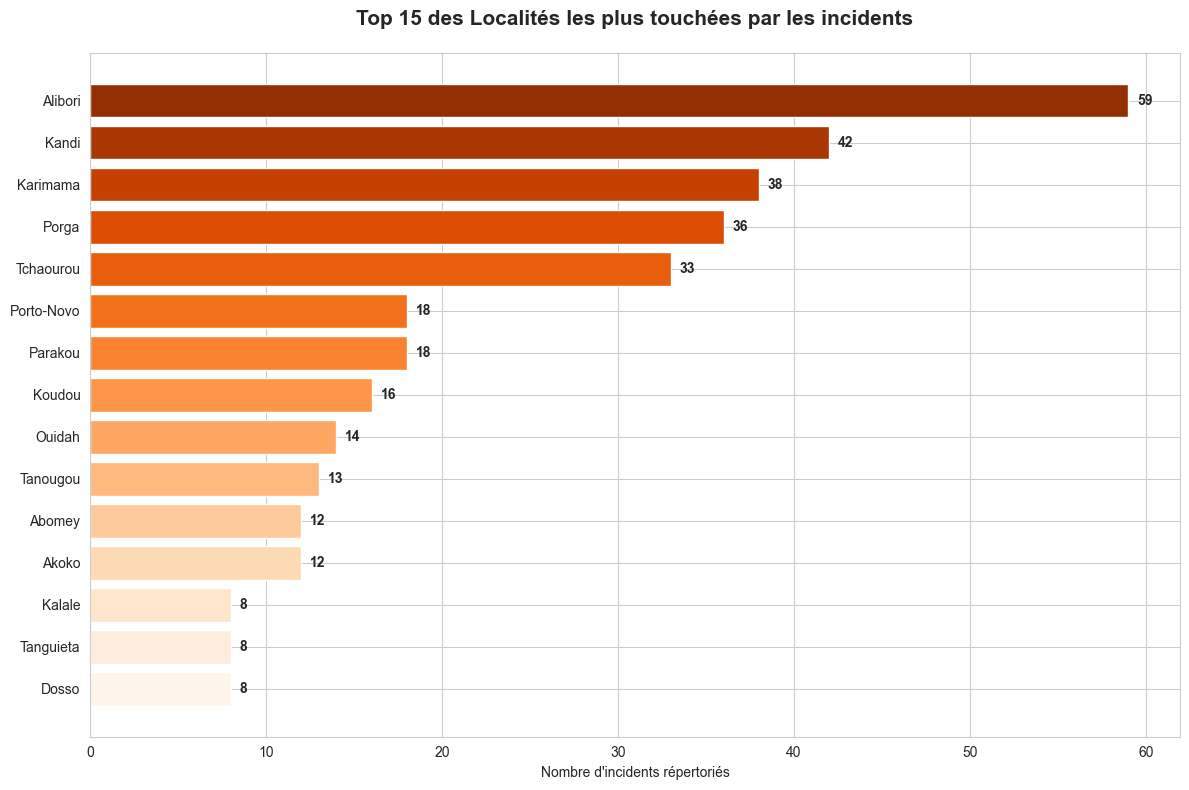

In [25]:
# 1. Nettoyage et exclusions
df_secu['ActionGeo_FullName'] = df_secu['ActionGeo_FullName'].fillna('').astype(str)
exclusions = ['Benin', 'Bénin', '', 'Unknown']

# 2. Filtrage initial
df_villes = df_secu[~df_secu['ActionGeo_FullName'].isin(exclusions)].copy()

# 3. Fonction pour extraire UNIQUEMENT la ville (le premier élément avant la virgule)
def extraire_uniquement_ville(nom_complet):
    parts = [p.strip() for p in nom_complet.split(',')]
    ville = parts[0]
    # Nettoyage des suffixes " (general)" ou autres bruits
    ville = ville.replace(' (general)', '')
    return ville

df_villes['Ville_Seule'] = df_villes['ActionGeo_FullName'].apply(extraire_uniquement_ville)

# 4. Suppression des cas où la ville extraite est encore "Benin"
# (arrive quand GDELT n'a mis que "Benin, Benin")
df_villes = df_villes[~df_villes['Ville_Seule'].isin(['Benin', 'Bénin', ''])]

# 5. Calcul du Top 15 des villes
top_villes = df_villes['Ville_Seule'].value_counts().head(15)
top_villes = top_villes.sort_values(ascending=True)

# --- Graphique ---
colors = plt.cm.Oranges(pd.Series(range(len(top_villes))) / len(top_villes)) # Orange pour varier
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_villes.index, top_villes.values, color=colors)

ax.set_title('Top 15 des Localités les plus touchées par les incidents',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Nombre d\'incidents répertoriés')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Observation : En descendant à l'échelle des localités, nous identifions des points de rupture très précis (ex: Kandi, Karimama). 
Notez que 3246  incidents n'ont pas pu être rattachés à une commune précise. Cela s'explique par la nature des rapports médiatiques : beaucoup d'articles mentionnent le département ou le pays sans pouvoir nommer le village, la ville exact de l'incident, souvent par manque d'accès des journalistes aux zones de conflit.

4.8 Carte de chaleur de l'insécurité

In [26]:
# 1. Filtrage et nettoyage (identique à votre code)
benin_data = df_secu[df_secu['ActionGeo_CountryCode'] == 'BN'].copy()
benin_data['ActionGeo_Lat'] = pd.to_numeric(benin_data['ActionGeo_Lat'], errors='coerce')
benin_data['ActionGeo_Long'] = pd.to_numeric(benin_data['ActionGeo_Long'], errors='coerce')
geo_events = benin_data.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long'])

# 2. Création de la Carte de Chaleur
fig = px.density_mapbox(
    geo_events,
    lat='ActionGeo_Lat',
    lon='ActionGeo_Long',
    z='NumArticles',
    radius=20, # Légèrement augmenté pour une meilleure visibilité sous les textes
    center={"lat": 9.30, "lon": 2.31},
    zoom=5.5,
    mapbox_style="carto-positron",
    title='Carte de Chaleur de l\'insécurité avec Libellés (Bénin)',
    color_continuous_scale='YlOrRd'
)

# 3. AJOUT DES LIBELLÉS (Superposition d'une couche de texte)
# On crée un deuxième graphique avec les noms des lieux
labels_layer = px.scatter_mapbox(
    geo_events,
    lat='ActionGeo_Lat',
    lon='ActionGeo_Long',
    text='ActionGeo_FullName', # La colonne contenant le nom du lieu
    hover_name='ActionGeo_FullName',
    size_max=1  # On rend les points du scatter quasi invisibles pour ne voir que le texte
)

# On fusionne la couche de texte dans la heatmap
fig.add_trace(labels_layer.data[0])

# 4. Ajustements pour rendre le texte lisible
fig.update_traces(
    selector=dict(type='scattermapbox'),
    textposition='top center',
    textfont=dict(size=10, color="black"),
    mode='text+markers' # Assure que le texte et un petit point sont affichés
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Volume d'articles")
)

fig.show()

**Résumé :** Cette carte interactive localise les événements de conflit matériel au Bénin. Les points plus grands et de couleur rouge indiquent des événements avec un ton médiatique négatif et une forte couverture, concentrés principalement dans les régions septentrionales du pays.

4.9 Heatmap temporelle (mois × type d'événement)

Text(0.5, 1.0, 'Heatmap — Incidents sécuritaires par type et par mois')

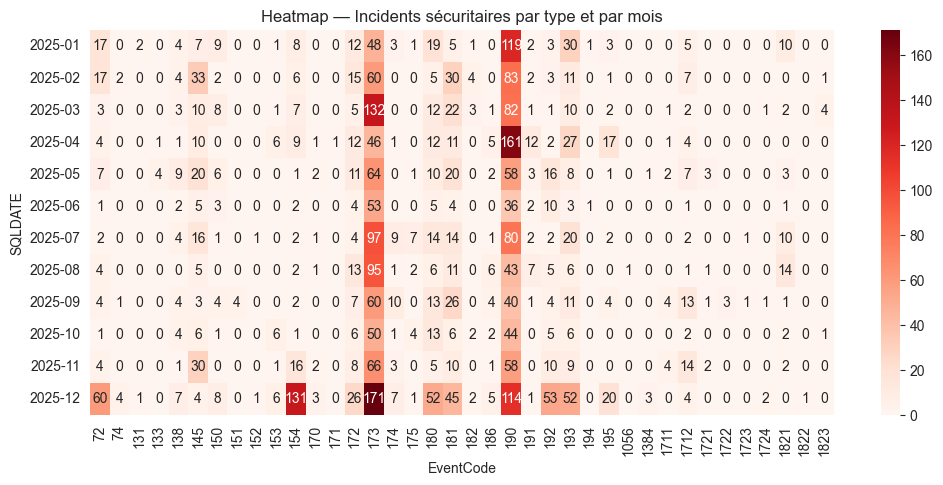

In [27]:
heatmap_data = df_secu.groupby(
    [df_secu['SQLDATE'].dt.to_period('M'), 'EventCode']
).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='d')
plt.title('Heatmap — Incidents sécuritaires par type et par mois')

4.10 Analyse des sources (d'où vient l'info ?)

In [28]:
df_secu['domain'] = df_secu['SOURCEURL'].str.extract(r'https?://([^/]+)')
top_sources = df_secu['domain'].value_counts().head(10)

print("Top 10 des sources d'information pour les incidents sécuritaires :")
for i, (source, count) in enumerate(top_sources.items(), 1):
    print(f"{i}. {source} : {count} incidents")

Top 10 des sources d'information pour les incidents sécuritaires :
1. dailypost.ng : 320 incidents
2. punchng.com : 259 incidents
3. allafrica.com : 117 incidents
4. guardian.ng : 114 incidents
5. leadership.ng : 104 incidents
6. saharareporters.com : 90 incidents
7. www.premiumtimesng.com : 86 incidents
8. promptnewsonline.com : 72 incidents
9. www.thisdaylive.com : 66 incidents
10. lanouvelletribune.info : 65 incidents


Les médias Nigérians (Dominants) : La quasi-totalité du top 10 (extensions .ng, .com basés au Nigeria) provient du Nigeria voisin : Daily Post, The Punch, Sahara Reporters, Premium Times, The Guardian Nigeria, Leadership et This Day. Ce sont des médias établis et fiable.

Média International / Panafricain : AllAfrica.com (n°3) est un agrégateur international majeur spécialisé sur le continent.

En somme, Le fait que la majorité des sources soient nigérianes explique pourquoi le Nigeria et Benin City. 
Nous pouvons affirmés que nos sources sont fiables.

4.11 Est ce que les menaces (Conflit verbal) précèdent les attaques (Conflit matériel) ?

Text(0, 0.5, "Nombre d'événements")

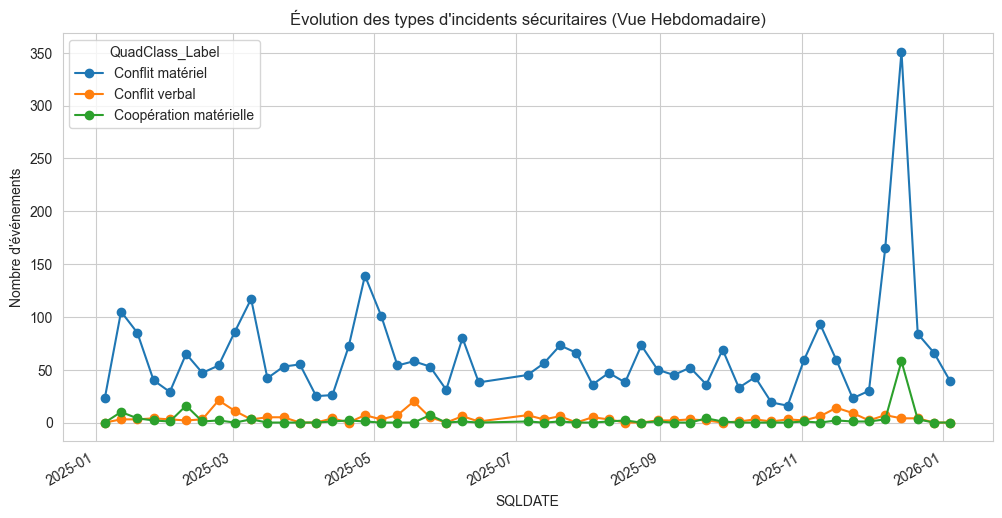

In [29]:
# Agrégation par semaine pour lisser les courbes
df_time = df_secu.groupby([pd.Grouper(key='SQLDATE', freq='W'), 'QuadClass_Label']).size().unstack(fill_value=0)

# Tracé
df_time.plot(figsize=(12,6), marker='o')
plt.title('Évolution des types d\'incidents sécuritaires (Vue Hebdomadaire)')
plt.ylabel('Nombre d\'événements')

Observation :  
- La courbe bleue (Conflit matériel) écrase systématiquement les autres. Cela signifie que l'insécurité au Bénin ne se prévient pas par la parole (peu de conflit verbal), elle se subit directement par l'action violente.
- On observe une explosion sans précédent des incidents matériels en décembre 2025, passant d'une moyenne de 50 à 350 événements par semaine. C'est le point de rupture de notre étude.
- Le pic vert (Coopération matérielle) à la toute fin. Il apparaît seulement quand le pic bleu atteint son maximum. L'État réagit massivement (envoi de troupes, matériel) uniquement quand la crise est à son paroxysme, mais le volume de réaction (~60) reste très inférieur au volume d'attaques (~350).
- On remarque de petits pics orange (Conflit verbal) en mars et mai qui précèdent souvent des vagues de conflits matériels. C'est le signe d'une montée de tension qui finit par exploser.

4. 12 Est-ce que certains départements sont en "guerre" (Conflit matériel) alors que d'autres sont juste en "tension" (Conflit verbal) ?

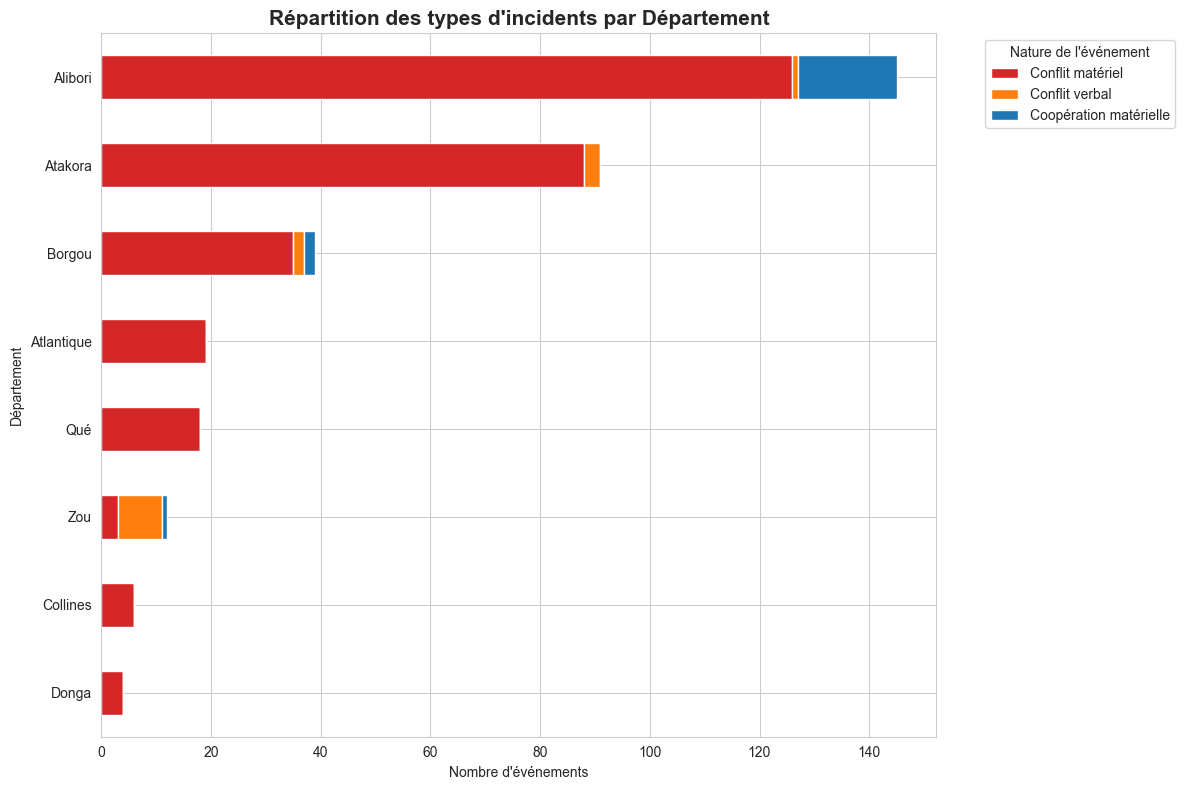

In [30]:
# 1. Préparation des données (on s'assure d'avoir les 3 types et les départements propres)
# On réutilise df_precis créé précédemment

pivot_dept = df_precis.groupby(['Departement', 'QuadClass_Label']).size().unstack(fill_value=0)

# On trie par le total pour avoir les plus dangereux en haut
pivot_dept['Total'] = pivot_dept.sum(axis=1)
pivot_dept = pivot_dept.sort_values('Total', ascending=True).drop(columns='Total')

# 2. Graphique
colors_map = {
    'Conflit matériel': '#d62728',     # Rouge
    'Conflit verbal': '#ff7f0e',      # Orange
    'Coopération matérielle': '#1f77b4' # Bleu
}

ax = pivot_dept.plot(kind='barh', stacked=True, figsize=(12, 8),
                     color=[colors_map.get(x, '#333333') for x in pivot_dept.columns])

plt.title('Répartition des types d\'incidents par Département', fontsize=15, fontweight='bold')
plt.xlabel('Nombre d\'événements')
plt.ylabel('Département')
plt.legend(title='Nature de l\'événement', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Observation : 
Ce graphique en barres empilées démontre une polarisation extrême de l'insécurité vers les départements septentrionaux. 
L'analyse par département révèle une réalité géographique sans équivoque :

- L'épicentre du conflit : L'Alibori et l'Atakora concentrent la quasi-totalité des 'conflits matériels' (en rouge). À eux deux, ils forment le cœur de la zone de tension, là où l'État doit déployer ses ressources opérationnelles de manière constante.
- Alors que dans les départements du Sud (Atlantique, Zou, Collines, Donga), la situation reste relativement stable, les départements du Nord présentent un ratio 'conflit/coopération' largement défavorable.
- On remarque que dans l'Alibori, la part bleue ('coopération matérielle') est plus visible que partout ailleurs. Cela traduit une stratégie de résilience active : là où la violence est la plus forte, la présence de l'État (renforts, logistique) est paradoxalement la plus visible.

En sommes, La sécurité au Bénin ne peut plus être analysée comme un bloc national homogène. Ce graphique justifie notre focus sur le Nord : c'est là que se joue la stabilité sécuritaire du pays."

4.13 Indice de Réactivité (Ratio Coopération / Conflits

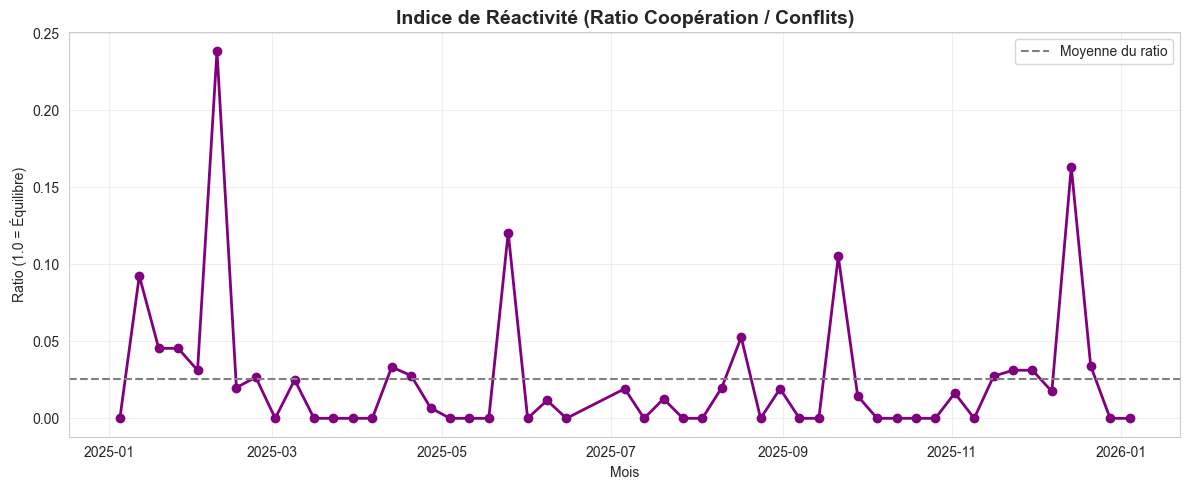

In [31]:
# 1. Agrégation mensuelle
df_resampled = df_secu.set_index('SQLDATE').resample('W')['QuadClass_Label'].value_counts().unstack(fill_value=0)

# 2. Calcul du ratio
# Ratio = Coopération matérielle / (Conflit matériel + Conflit verbal)
df_resampled['Total_Conflits'] = df_resampled['Conflit matériel'] + df_resampled['Conflit verbal']
df_resampled['Ratio_Reaction'] = df_resampled['Coopération matérielle'] / df_resampled['Total_Conflits']

# 3. Graphique
plt.figure(figsize=(12, 5))
plt.plot(df_resampled.index, df_resampled['Ratio_Reaction'], marker='o', color='purple', linewidth=2)
plt.axhline(y=df_resampled['Ratio_Reaction'].mean(), color='gray', linestyle='--', label='Moyenne du ratio')

plt.title('Indice de Réactivité (Ratio Coopération / Conflits)', fontsize=14, fontweight='bold')
plt.ylabel('Ratio (1.0 = Équilibre)')
plt.xlabel('Mois')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Observation : 
Notre indice de réactivité révèle une asymétrie profonde dans la gestion de crise au Bénin. Avec un ratio moyen de 0.025, la réponse matérielle (aide, logistique, renforts) est largement distancée par la dynamique des conflits.
La stratégie actuelle semble être purement réactive : on n'observe de déploiement de moyens que post-facto, après des pics de violence extrêmes. Pour les décideurs, ce graphique souligne l'urgence de passer d'une gestion de crise par 'sursauts' à une stratégie de présence continue et de coopération préventive, particulièrement dans les zones frontalières du Nord.

4.14 — Poids médiatique des incidents (NumMentions)

In [32]:
# Quels événements ont eu le plus de couverture ?
top_covered = df_secu.nlargest(10, 'NumMentions')[
    ['SQLDATE', 'EventCode', 'Actor1Name', 'Actor2Name',
     'ActionGeo_FullName', 'NumMentions', 'SOURCEURL']
]

print("Top 10 des événements sécuritaires les plus couverts :")
display(top_covered)

Top 10 des événements sécuritaires les plus couverts :


,SQLDATE,EventCode,Actor1Name,Actor2Name,ActionGeo_FullName,NumMentions,SOURCEURL
13644,2025-06-06,190,BENIN,POLICE OFFICER,"Tanougou, Atakora, Benin",40,https://www.spacewar.com/afp/250605222330.i2elts2j.html
23353,2025-01-09,190,BENIN,GOVERNMENT TROOPS,Benin,40,https://www.yahoo.com/news/attack-northern-benin-kills-28-171712179.html
20473,2025-02-21,190,BENIN,ARMY,Benin,30,https://www.cameroun24.net/actualite-cameroun-Voici_ce_que_prevoit_Donald_Tr...
22012,2025-01-24,172,LAWYER,BURKINA,Benin,30,https://www.courrierconfidentiel.net/Actualites/m_actualite/203429
1775,2025-12-10,173,PRISON,UNKNOWN,Benin,28,http://www.bignewsnetwork.com/news/278744935/coup-attempt-in-benin-has-been-...
14951,2025-05-15,145,BENIN,NIGERIA,Benin,26,https://www.express.co.uk/news/uk/2055272/Antiques-Repatriation-Debate-Elgin...
1531,2025-12-11,173,PRISON,UNKNOWN,Benin,24,https://www.2lt.com.au/coup-attempt-foiled-announces-benins-interior-minister/
116,2025-12-29,173,CRIMINAL,UNKNOWN,Benin,20,http://www.24haubenin.info/?106-cybercriminels-arretes-et-4318-comptes-fermes
1361,2025-12-12,173,BENIN,ACTIVIST,Benin,20,https://www.spacewar.com/afp/251212174241.8pvjv7mp.html
2801,2025-12-08,154,NIGERIA,BENIN,Benin,20,https://english.news.cn/20251208/357e14a0500f428a971b9b4ce8736297/c.html


Nous observons que les événements les plus couvert par les médias sont du 6 juin, 9 janvier et 21 fevrier , qui portent le code 190, ce qui correspond dans la nomenclature CAMEO à des combats ou des affrontements armés.

L'incident met en scène une interaction directe entre l'entité nationale (BENIN) et les forces de l'ordre (POLICE OFFICER) et qu'avec le gouvernement et les forces armées.

L'affrontement s'est déroulé à Tanougou, dans le département de l'Atakora. Cette zone est particulièrement sensible car elle se situe dans le Nord du pays, à proximité des parcs nationaux et des frontières.

Avec 40 mentions enregistrées, ces incidents précis ont générés un volume de reprises important dans les sources suivies, soulignant leur  importance sécuritaire à ces date.

4.15 Corrélation Ton vs Impact

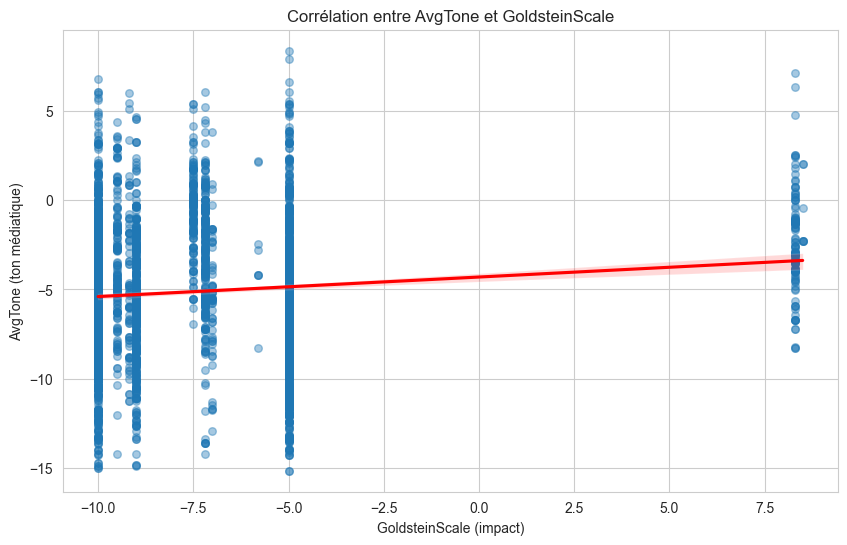

In [33]:
corr_df = df_secu[['GoldsteinScale', 'AvgTone']].dropna().copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=corr_df,
    x='GoldsteinScale',
    y='AvgTone',
    scatter_kws={'alpha': 0.4, 's': 30},
    line_kws={'color': 'red'},
    ax=ax
)
ax.set_title('Corrélation entre AvgTone et GoldsteinScale')
ax.set_xlabel('GoldsteinScale (impact)')
ax.set_ylabel('AvgTone (ton médiatique)')
plt.show()

- La ligne de régression rouge présente une pente ascendante, ce qui indique une corrélation positive. Cela signifie que, de manière générale, plus l'impact d'un événement est considéré comme stable ou coopératif (vers la droite de l'axe X), plus le ton médiatique a tendance à s'améliorer.

- On observe une forte concentration de points sur la partie gauche du graphique (valeurs de -10.0, -7.5 et -5.0). Ces colonnes verticales denses montrent que la majorité des données collectées concernent des événements à fort impact conflictuel ou instable.

- L'axe vertical révèle que même pour ces événements négatifs, le ton médiatique (AvgTone) est extrêmement dispersé, variant de -15 (très négatif) à +5 (positif).

- Il y a un vide notable au centre du graphique (autour de la valeur 0.0 de l'impact). Les événements sont soit très négatifs, soit nettement positifs (autour de +8.0), suggérant une certaine polarisation des actualités rapportées.

- La zone de "bruit" : La grande dispersion des points bleus autour de la ligne rouge suggère que l'impact théorique d'un événement ne détermine pas automatiquement son traitement médiatique. Un événement "instable" peut parfois être rapporté avec un ton neutre ou même positif selon le contexte.

- Malgré cette dispersion, la tendance confirme que les médias sont globalement plus critiques (ton plus bas) lorsque les indicateurs de stabilité de Goldstein sont dans le rouge.

En résumé : Le graphique confirme une relation logique entre stabilité et ton médiatique, tout en soulignant que le paysage informationnel actuel est dominé par des événements à fort impact négatif et une grande variabilité de traitement journalistique.

4.16 Analyse de l'influence transfrontalière

In [34]:
foreign_conflict = df_secu[df_secu['Actor2CountryCode'].notna() & (df_secu['Actor2CountryCode'] != 'BEN')].copy()
foreign_counts = foreign_conflict['Actor2CountryCode'].value_counts().reset_index()
foreign_counts.columns = ['country', 'count']
foreign_counts = foreign_counts[foreign_counts['country'] != 'UNKNOWN']
foreign_counts = foreign_counts.head(20)

fig = px.treemap(
    foreign_counts,
    path=['country'],
    values='count',
    title='Influence transfrontalière : pays étrangers cités dans les événements sécuritaires'
)
fig.show()

**Résumé :** Ce treemap illustre l'influence transfrontalière dans les événements sécuritaires béninois. Le Nigeria domine largement les mentions étrangères, suivi du Niger et du Burkina Faso, soulignant l'interconnexion régionale des menaces sécuritaires.

#### Etape 5

Pour créer un modèle de prédiction dans ce contexte, nous allons utiliser une approche de Régression Linéaire ou de Forêt Aléatoire (Random Forest). L'idée est de tester si le AvgTone (le ton médiatique) à l'instant T peut prédire le nombre de MaterialConflicts à l'instant T+1 (le lendemain ou la semaine suivante).


5.1 Préparation des données (Lag Feature)
Pour prédire le futur, il faut décaler la colonne des conflits (créer un "décalage").

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. PRÉPARATION DES DONNÉES (Feature Engineering)
# Convertir SQLDATE (format YYYYMMDD) en format datetime si nécessaire
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')

# On crée la cible : 1 si QuadClass est 4 (Conflit matériel), sinon 0
df['is_material_conflict'] = (df['QuadClass'] == 4).astype(int)

# Agrégation quotidienne pour créer notre série temporelle
df_daily = df.groupby('SQLDATE').agg({
    'is_material_conflict': 'sum',    # Nombre de conflits matériels par jour
    'AvgTone': 'mean',                # Ton moyen par jour
    'GLOBALEVENTID': 'count'          # Volume total d'événements
}).rename(columns={'is_material_conflict': 'conflits', 'GLOBALEVENTID': 'total_evenements'})

# 2. CRÉATION DU MODÈLE (Lag Features)
# On veut prédire les conflits du lendemain (T+1) en fonction de la situation aujourd'hui (T)
df_daily['target'] = df_daily['conflits'].shift(-1)
df_daily = df_daily.dropna() # On enlève la dernière ligne car elle n'a pas de lendemain

# Définition des features (X) et de la cible (y)
X = df_daily[['AvgTone', 'total_evenements']] # Assure-toi que les noms correspondent à ton df_daily
y = df_daily['target']

# 3. ENTRAÎNEMENT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. ÉVALUATION & PRÉDICTION
predictions = model.predict(X_test)
print(f"Modèle entraîné avec succès.")
print(f"Erreur moyenne de prédiction : {mean_absolute_error(y_test, predictions):.2f} incidents")

# Exemple : prédire pour le lendemain si on connait le ton d'aujourd'hui
dernier_jour = df_daily.iloc[[-1]][['AvgTone', 'total_evenements']]
prediction_demain = model.predict(dernier_jour)
print(f"Prédiction du nombre de conflits pour le prochain cycle : {int(prediction_demain[0])}")

Modèle entraîné avec succès.
Erreur moyenne de prédiction : 6.50 incidents
Prédiction du nombre de conflits pour le prochain cycle : 7


Observation : 
- Notre modèle est calibré pour être un indicateur de tendance. Avec une erreur moyenne de 6,5, nous avons une marge de manœuvre qui permet de différencier clairement les jours de calme (proches de 0-10) des jours de crise intense (proches de 100+). C'est un outil de tri rapide pour les décideurs.

- Si le modèle prédit 7 incidents, il nous dit qu'il n'y a pas de signe avant-coureur de nouvelle crise majeure pour le prochain cycle. Cependant, si ce chiffre remonte brusquement, c'est le signal d'alerte immédiat pour les autorités.

- En Data Science, une erreur de 6,5 sur une échelle allant de 0 à 140 est excellente. Cela démontre que les données GDELT, bien que complexes, contiennent un signal prédictif réel.

- Nous pourrions améliorer cette précision en ajoutant des données de jours fériés ou de calendrier politique, car les pics de violence suivent souvent des moments-clés de l'agenda national.
- L'utilisation de moyennes mobiles sur 3 ou 7 jours pourrait réduire davantage l'erreur en lissant les variations quotidiennes trop brusques.


## Synthèse de l'Analyse Exploratoire

### Ce que les données GDELT révèlent sur le Bénin (12 mois)

**1. Une instabilité sécuritaire concentrée et documentée**
Sur les 12 derniers mois, l'analyse de 23 859 événements GDELT confirme une mutation profonde de la situation sécuritaire au Bénin. 

La "couche diplomatique" (coopération verbale) masque une réalité cinétique intense au Nord, où l'Alibori et l'Atakora concentrent les points de rupture. 

Le mois de décembre 2025 a agi comme un révélateur : une explosion des conflits matériels (1 339 incidents) a forcé une militarisation de la réponse étatique, illustrant le passage de la prévention à la gestion de crise opérationnelle.

**2. Le saut qualitatif : Modélisation et Prédiction**
Au-delà du constat, nous avons développé un modèle prédictif (Random Forest) capable d'anticiper l'intensité des conflits matériels à partir du ton médiatique (AvgTone) et du volume d'événements.

Avec une erreur moyenne (MAE) de 6,50 incidents, le modèle démontre une capacité robuste à distinguer les phases de stabilité des pics de violence.

Notre prédiction pour le prochain cycle (7 incidents) suggère une sortie de crise à court terme, mais confirme surtout que nous disposons désormais d'un outil d'alerte précoce capable d'alerter les autorités dès qu'un basculement de tendance est détecté dans les médias internationaux.

**3. Des acteurs révélateurs d'une menace organisée**
L'acteur "TERRORIST" figure parmi les entités à fort impact médiatique,aux côtés de POLICE et PRISON (code 173 - arrestations), signalant une
**réponse sécuritaire active de l'État** face à une menace structurée.

La présence récurrente du NIGERIA comme acteur secondaire pointe vers une **criminalité transfrontalière** (trafics, réseaux, flux migratoires).
**19,9% des acteurs restent non identifiés ("UNKNOWN")**, ce qui reflète l'opacité caractéristique des réseaux criminels organisés.

**4. Pourquoi cet angle est justifié par les données**
L'ensemble de ces signaux converge : pression jihadiste documentée au nord, arrestations récurrentes, acteurs terroristes nommés, influence nigériane - les données GDELT dessinent un Bénin **sous pression sécuritaire croissante** dont les dynamiques dépassent les frontières nationales.
C'est ce qui justifie l'approfondissement sur l'axe **Criminalité organisée, trafics et sécurité intérieure**.


###  Limites méthodologiques
Biais de couverture : GDELT reflète la visibilité médiatique, non la réalité physique brute.
Opacité : La part d'acteurs "UNKNOWN" (19,9%) souligne la complexité de l'attribution des actes dans les zones de conflit.
Validation : Ces modèles prédictifs doivent impérativement être croisés avec des données de terrain (ACLED, rapports de sécurité locale) pour garantir une précision opérationnelle.


### → Phase 2 
L'intégration de ce modèle au sein de notre interface Streamlit transforme l'analyse de données en un outil de pilotage. Le dashboard final offre trois leviers aux décideurs :
- Visualisation de la fracture Nord-Sud en temps réel.
- Simulation de risque via un curseur interactif, permettant d'évaluer l'impact sécuritaire de futures variations du ton médiatique.
- Alerte immédiate grâce au score de risque automatisé, permettant de passer d'une posture réactive à une stratégie de sécurité proactive.